# Packages

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch

import neurokit2 as nk

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss

from sklearn.ensemble import BaggingClassifier

from google.colab import drive
import random
import joblib

# Data Loading & Data Exploration

The dataset considered in this study is the WESAD (Wearable Stress and Affect Detection) dataset, which was downloaded directly from the following Kaggle link: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset.

After downloading, the dataset was uploaded to Google Drive, retaining only the .pkl files corresponding to the selected subjects required for our analysis. Before proceeding with the data loading phase, Google Drive is mounted in Google Colab in order to access these files within the execution environment.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Once Google Drive is successfully mounted, the .pkl files corresponding to the selected subjects are loaded into the Colab environment for subsequent preprocessing and analysis.

In [ ]:
# Local folder where the .pkl files have been copied
local_wesad_path = '/content/drive/MyDrive/WESAD'

# List of .pkl files into the folder
patient_files = [os.path.join(local_wesad_path, f)
                 for f in os.listdir(local_wesad_path)
                 if f.endswith(".pkl")]



Although each .pkl file contains multiple signals from both chest (RespiBAN) and wrist (Empatica E4) devices, as well as additional synchronization and metadata, only the chest ECG signal and the corresponding labels are considered in this study. This choice is made because the focus of our analysis is the classification of stress versus no-stress conditions based on the ECG data.

For the chosen patient, the ECG signal from the chest channel is extracted and flattened to ensure a one-dimensional array. The corresponding labels are then retrieved and converted into a binary format, where 0 indicates no-stress and 1 indicates stress. Finally, the ECG signal is separated into segments according to these two classes for further analysis.

In [ ]:
# Select which patient to load
patient_file = patient_files[0]  # Change the index for another patient
patient_name = os.path.basename(patient_file).replace(".pkl", "")

# Load patient data
with open(patient_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Extract ECG signal and labels
ecg = data["signal"]["chest"]["ECG"].flatten()  # flatten to 1D array
labels = data["label"]

# Convert labels to binary: 0 = no stress, 1 = stress
binary_labels = np.zeros_like(labels)
binary_labels[labels == 2] = 1

# Segment ECG according to class
ecg_no_stress = ecg[binary_labels == 0]
ecg_stress = ecg[binary_labels == 1]

For the chosen patient, the number of ECG samples corresponding to no-stress and stress conditions is displayed to provide an overview of the data distribution between the two classes.

In [ ]:
# Basic info
print(f"Patient: {patient_name}")
print("Samples No Stress:", len(ecg_no_stress))
print("Samples Stress:", len(ecg_stress))

Patient: S10
Samples No Stress: 3339700
Samples Stress: 507500


To conclude the exploratory analysis, we implement the following function, which allows us to visualize the ECG signals, stress segments, and related information for all patients within a single output, providing a comprehensive overview of the dataset.

Patient: S10
Samples No Stress: 3339700
Samples Stress: 507500


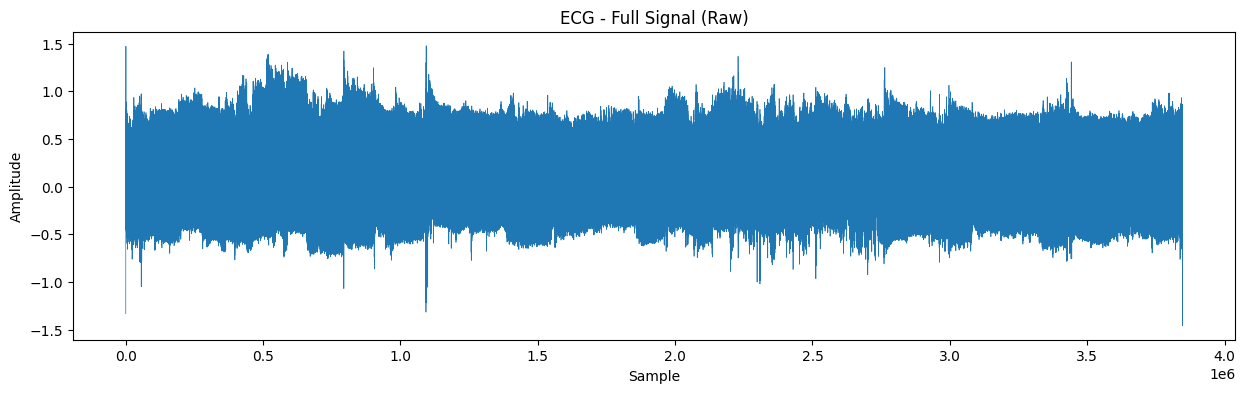

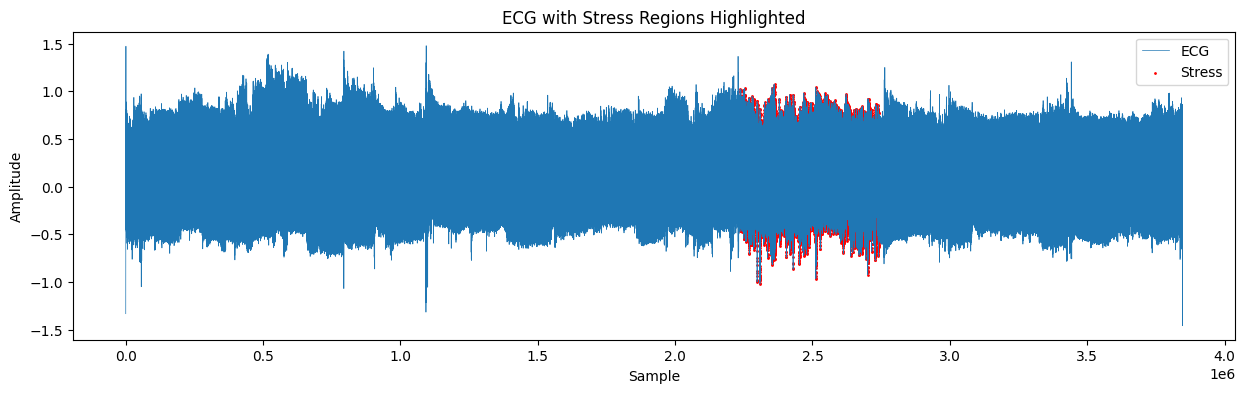

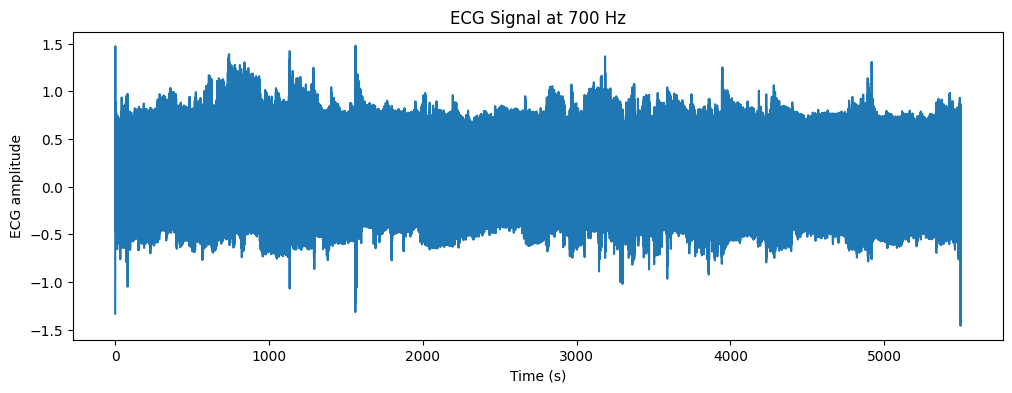

Patient: S11
Samples No Stress: 3187100
Samples Stress: 476000


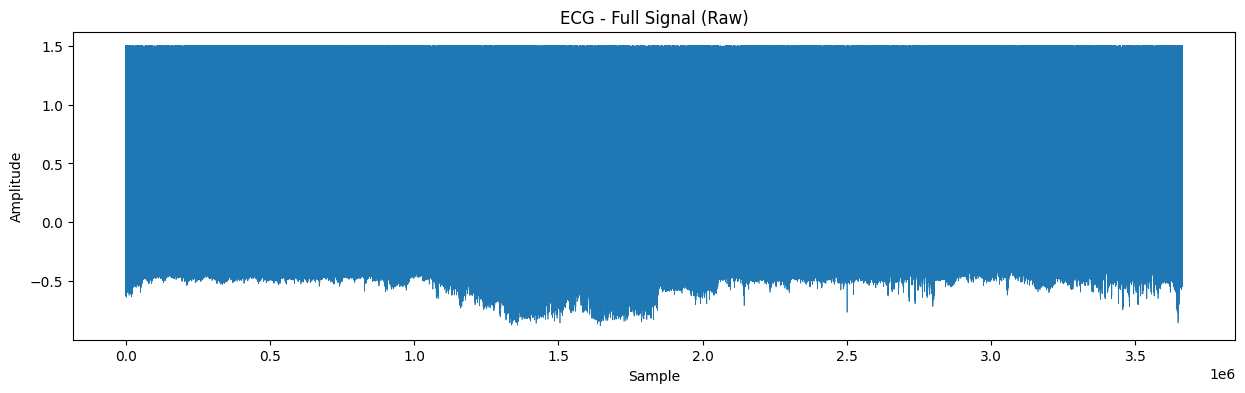

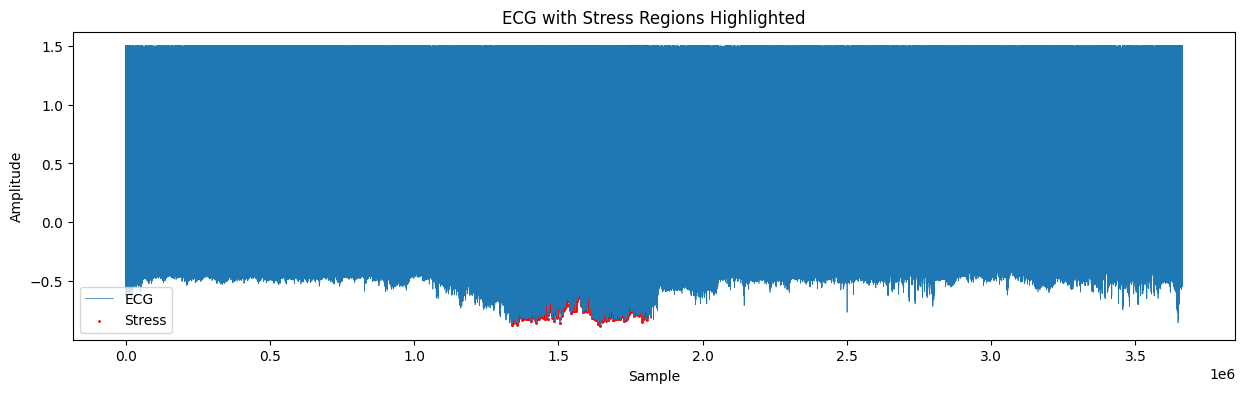

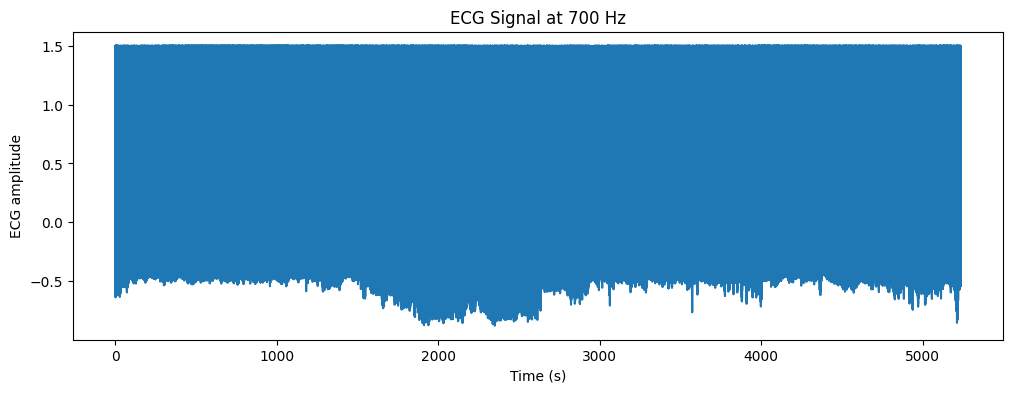

Patient: S13
Samples No Stress: 3411100
Samples Stress: 464800


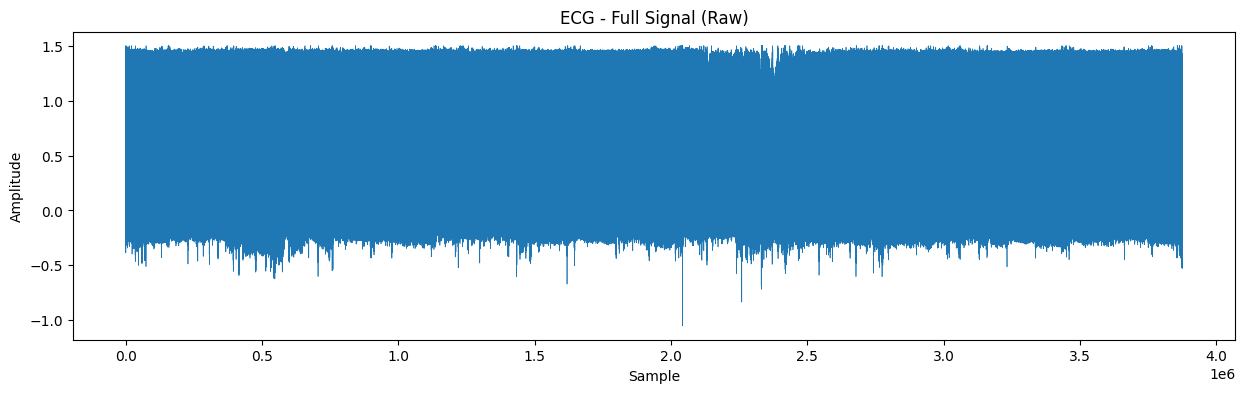

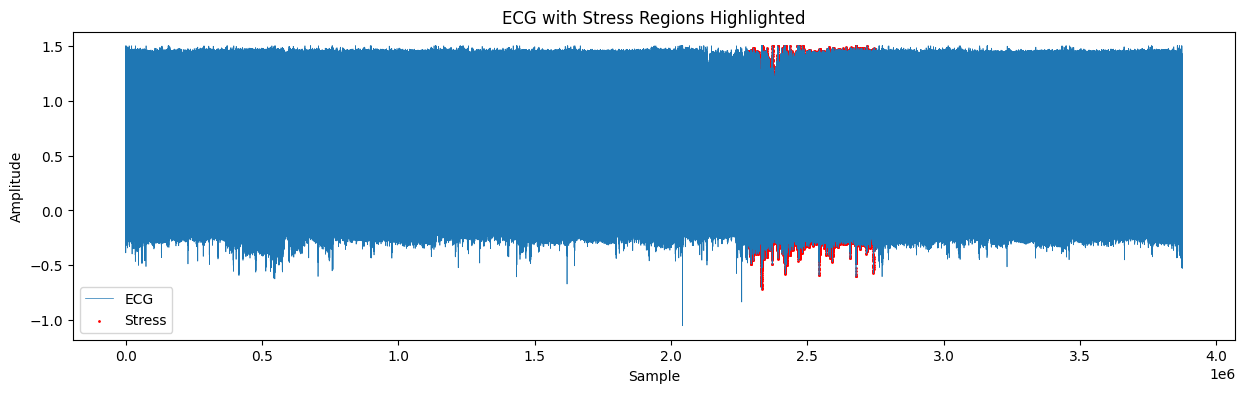

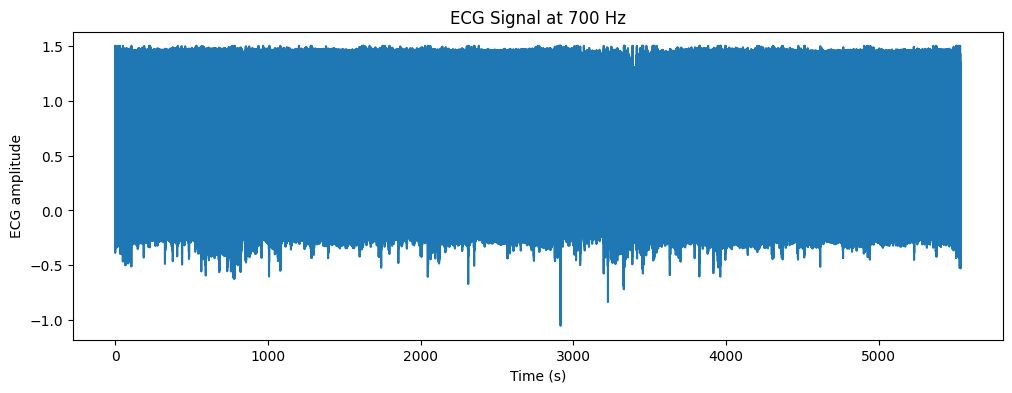

Patient: S14
Samples No Stress: 3411100
Samples Stress: 472500


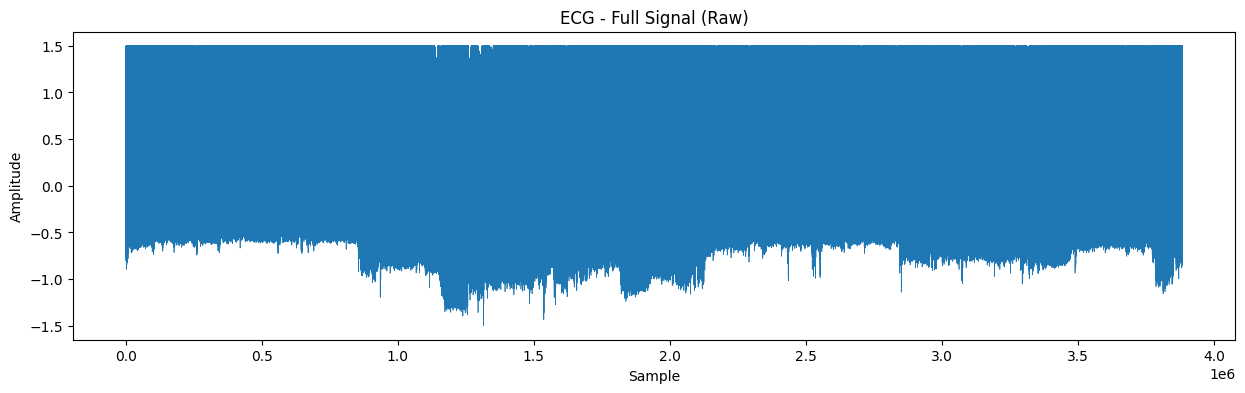

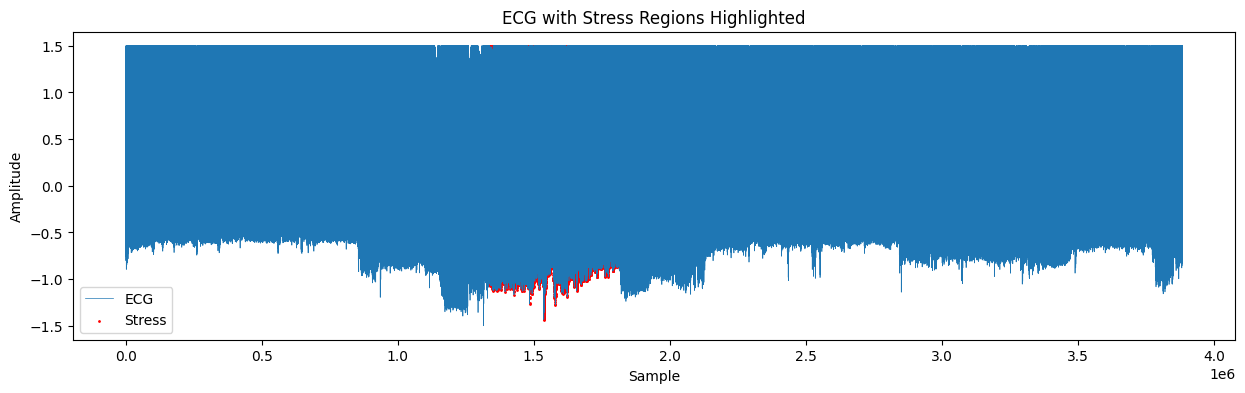

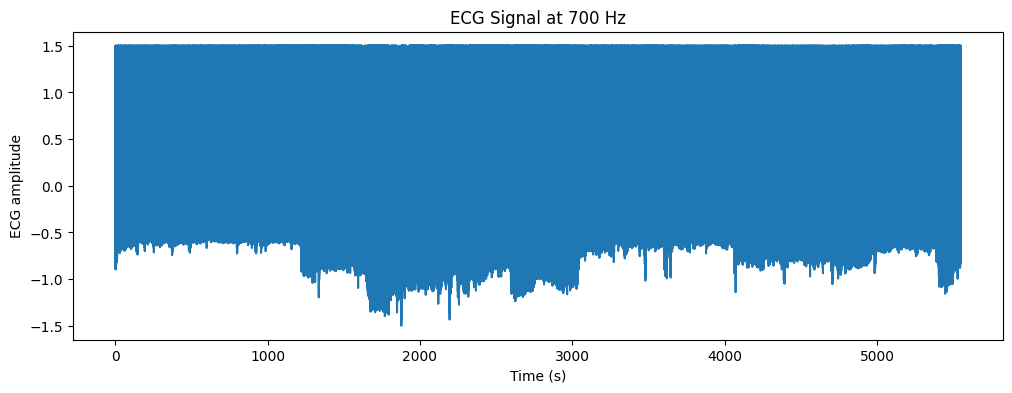

Patient: S15
Samples No Stress: 3196200
Samples Stress: 480200


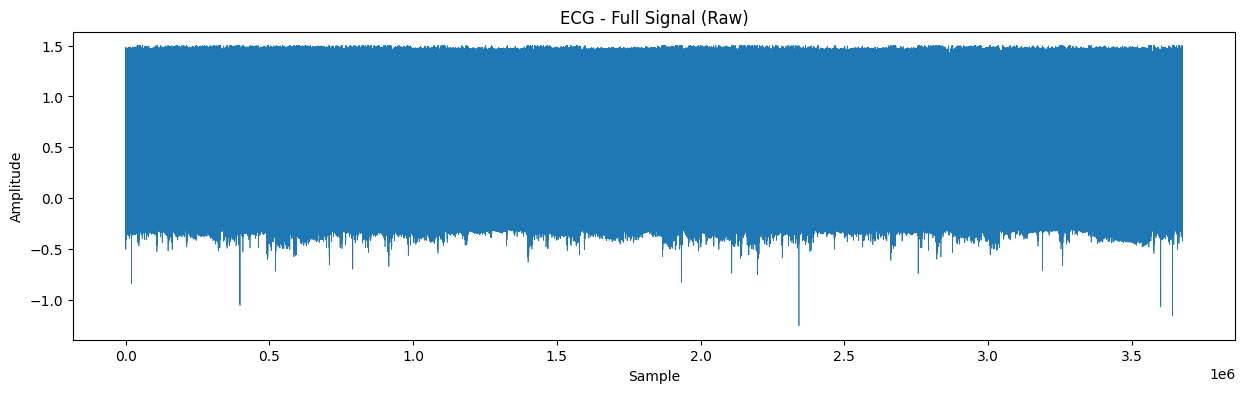

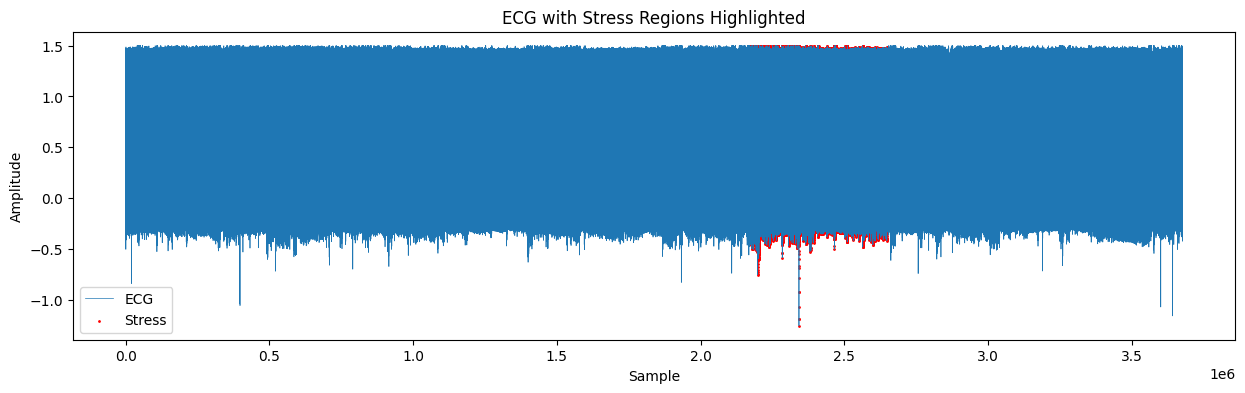

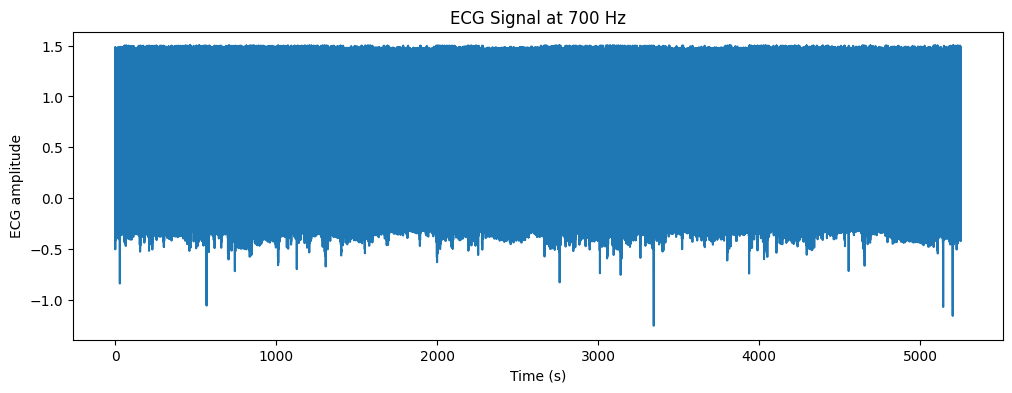

Patient: S16
Samples No Stress: 3470599
Samples Stress: 471101


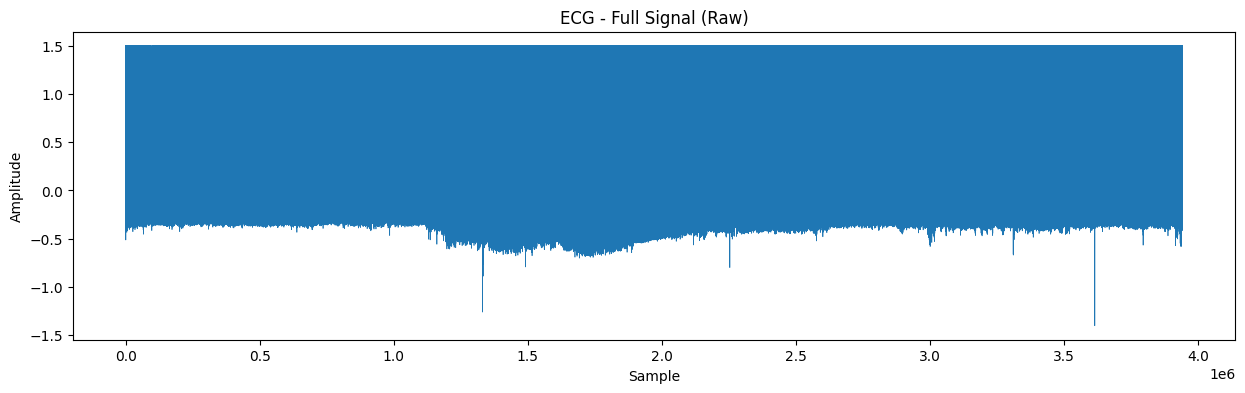

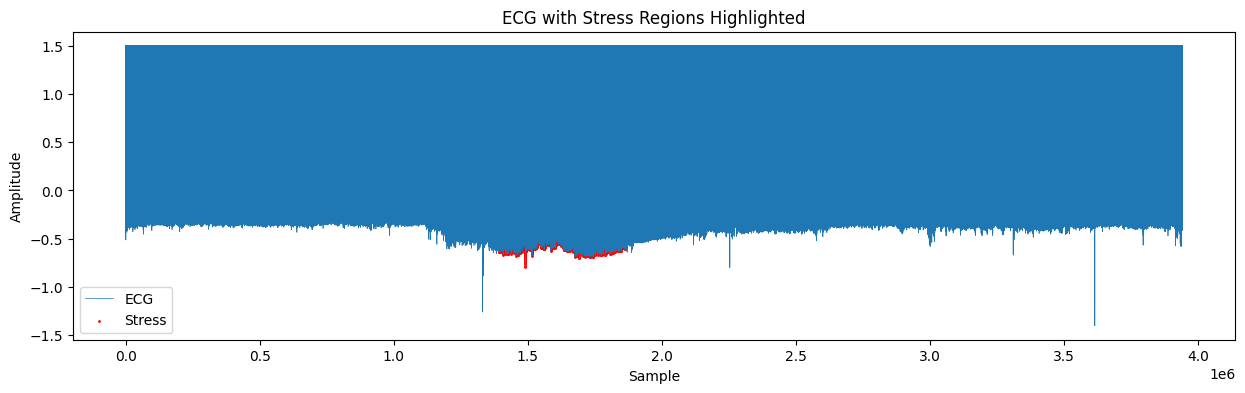

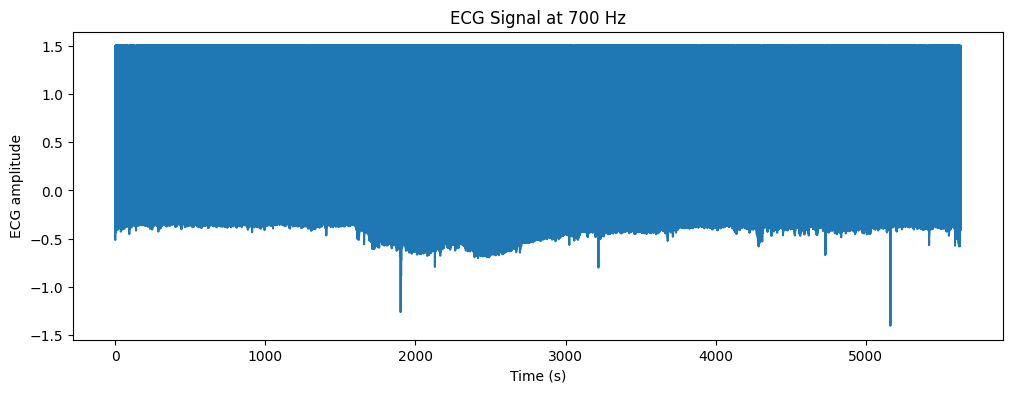

Patient: S17
Samples No Stress: 3637900
Samples Stress: 506100


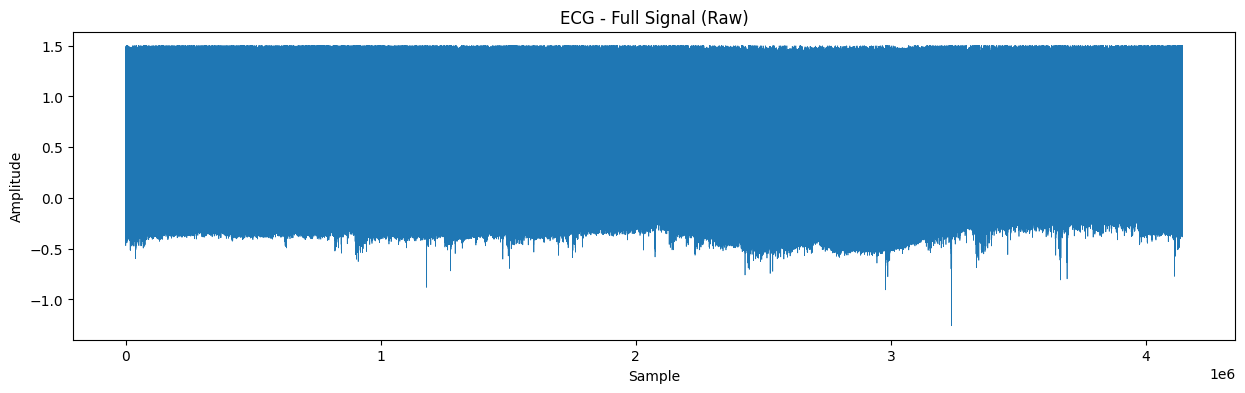

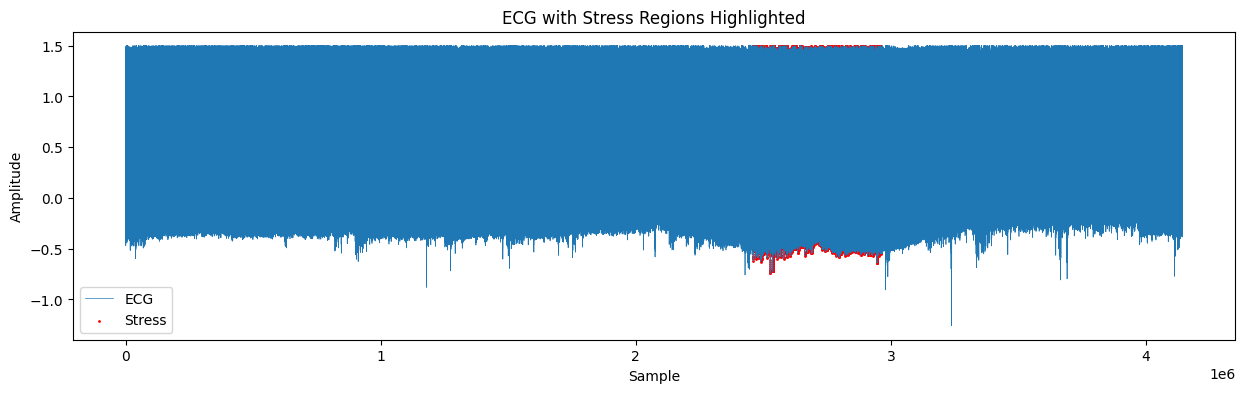

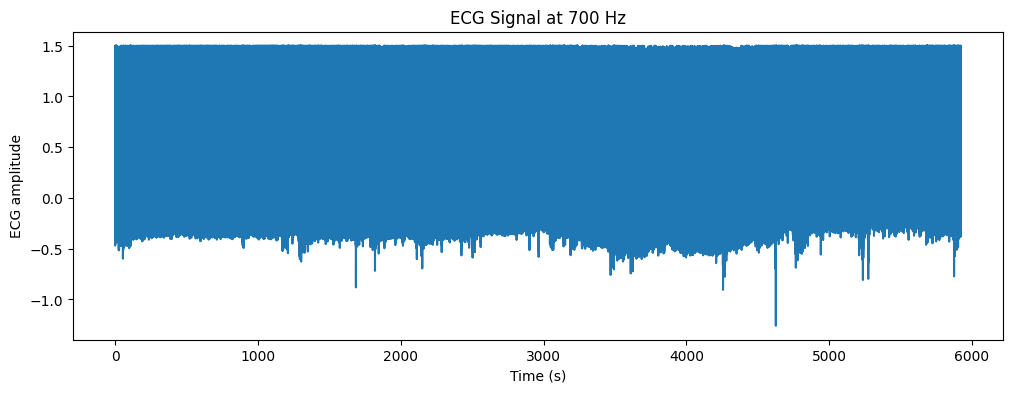

Patient: S2
Samples No Stress: 3824800
Samples Stress: 430500


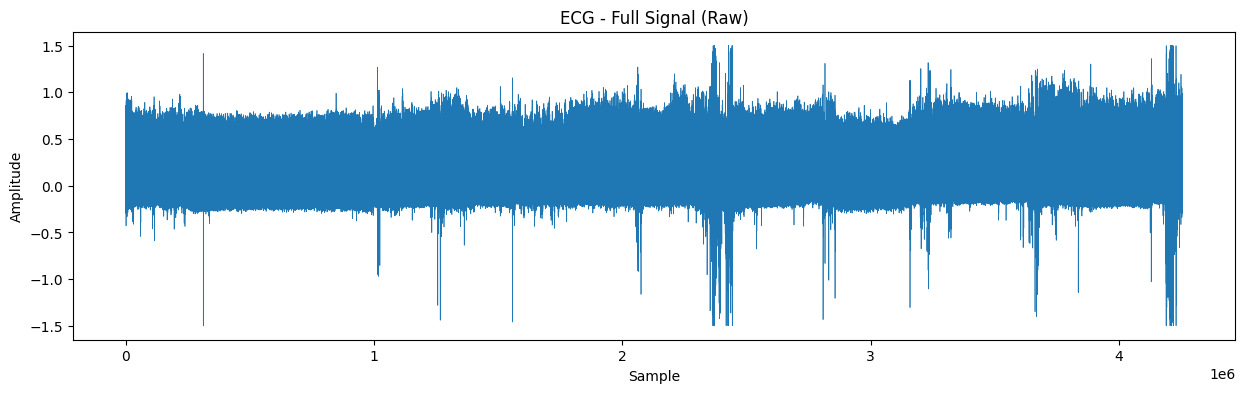

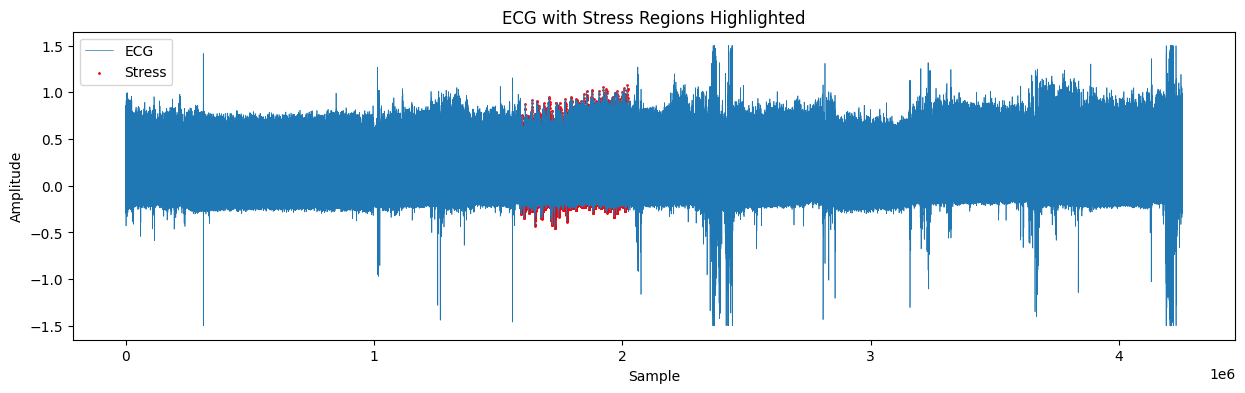

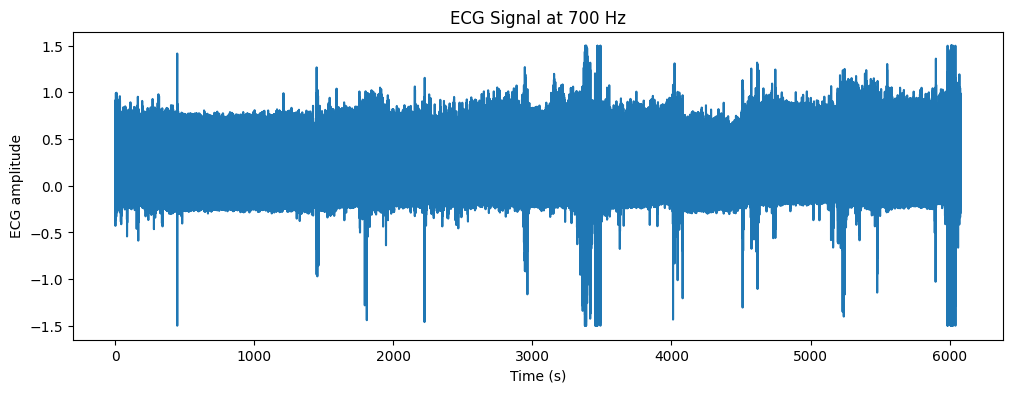

Patient: S3
Samples No Stress: 4097100
Samples Stress: 448000


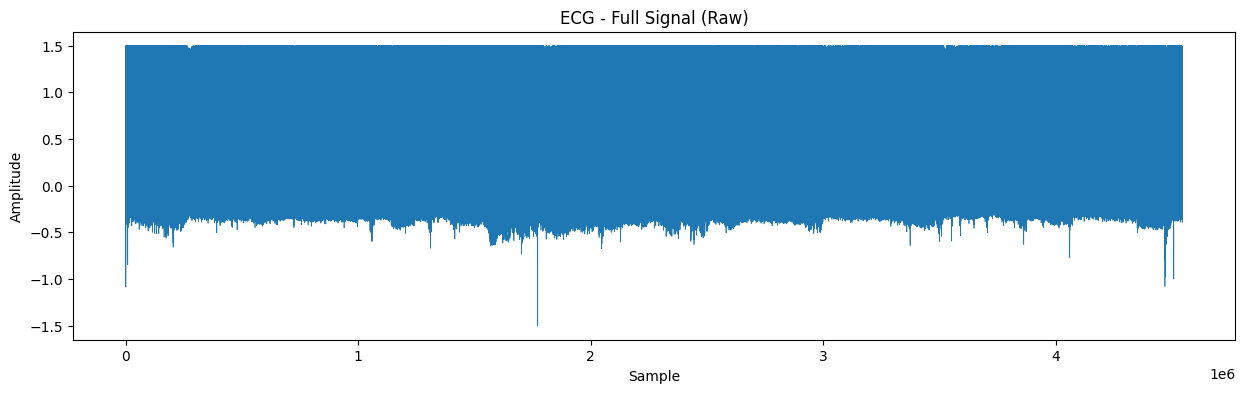

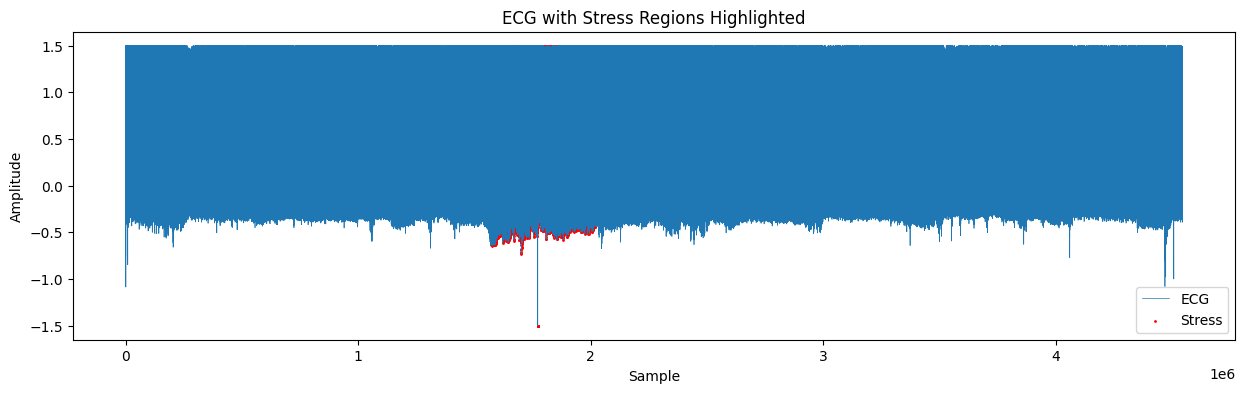

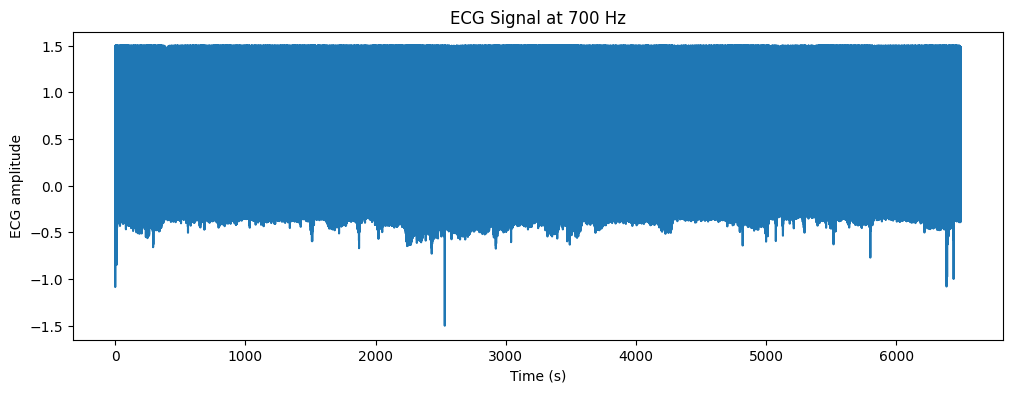

Patient: S4
Samples No Stress: 4051600
Samples Stress: 444500


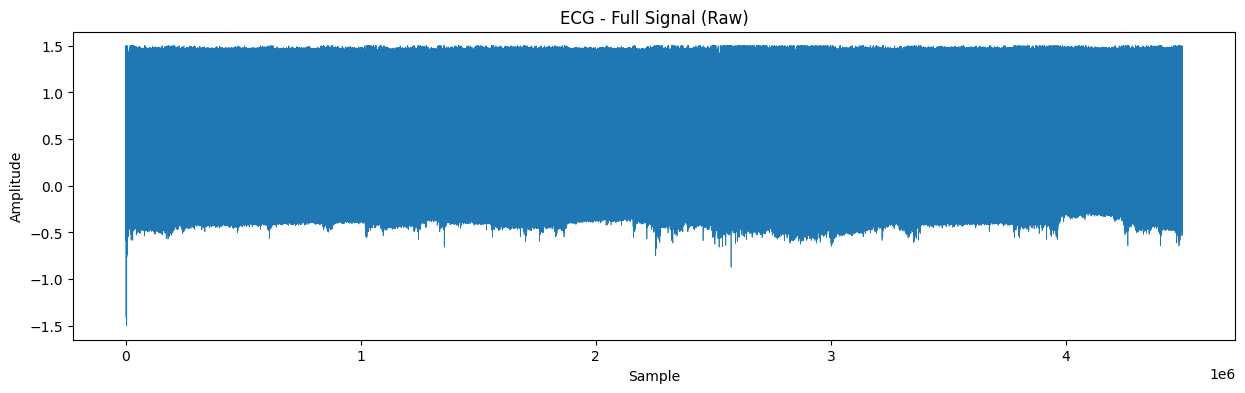

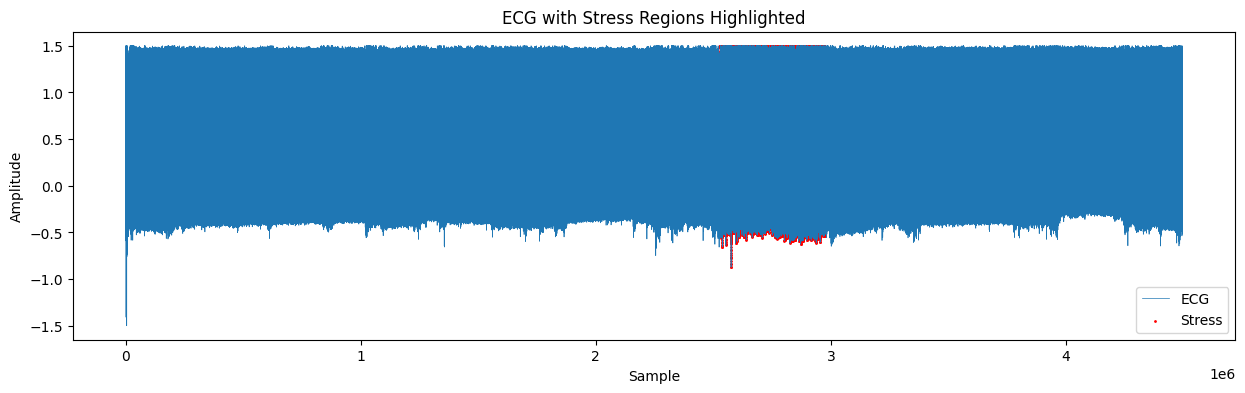

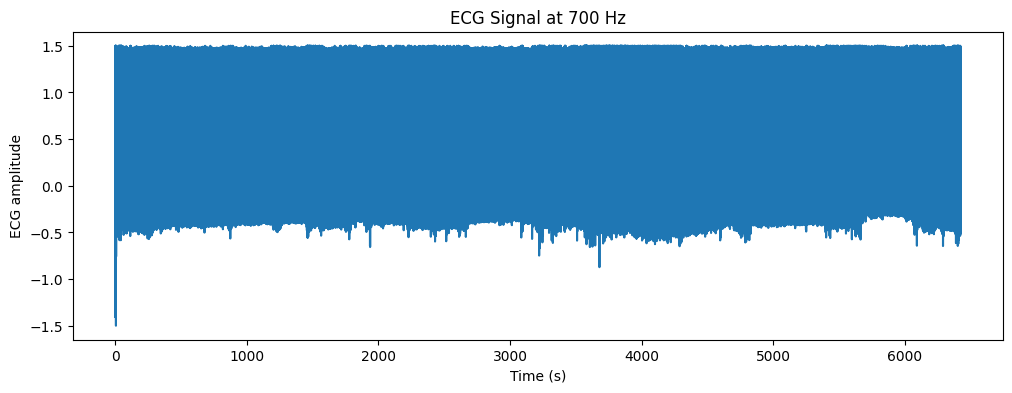

Patient: S5
Samples No Stress: 3929100
Samples Stress: 451500


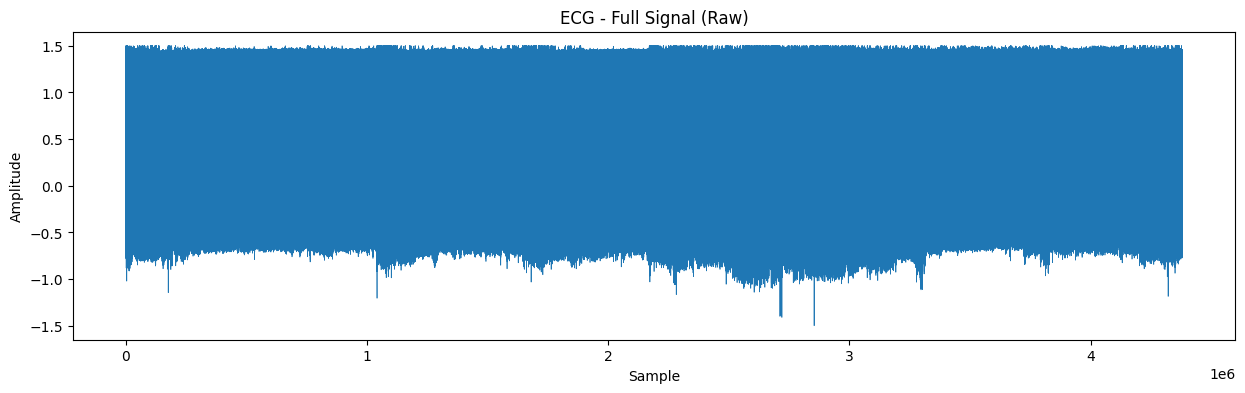

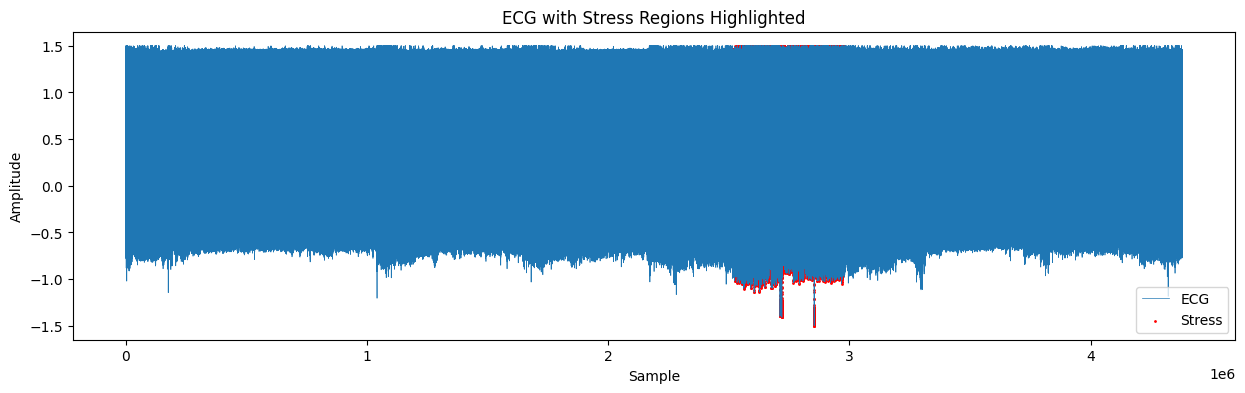

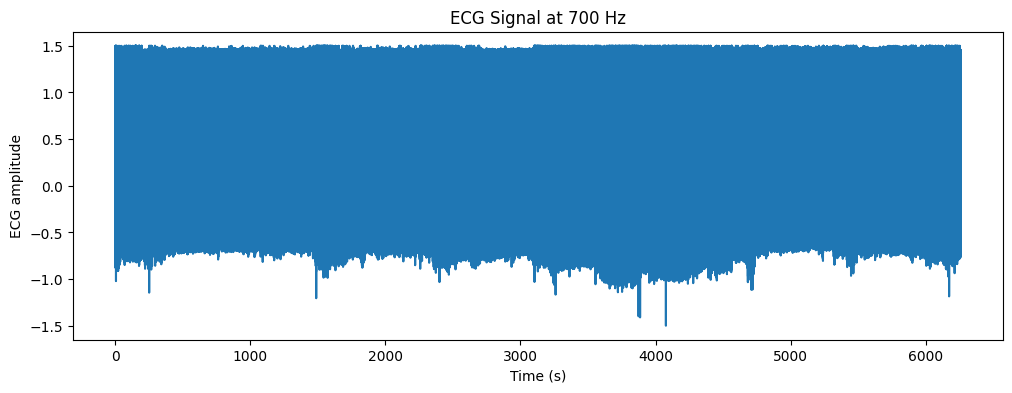

Patient: S6
Samples No Stress: 4494700
Samples Stress: 455000


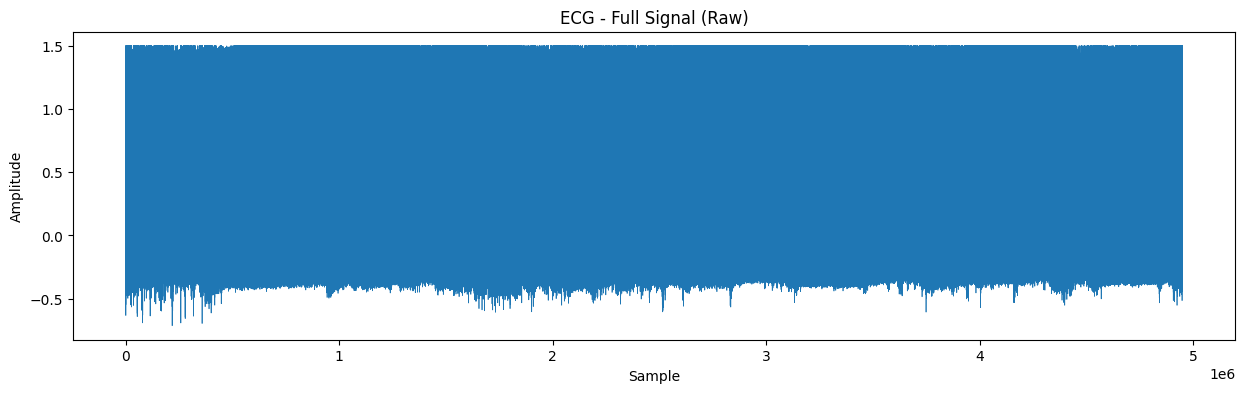

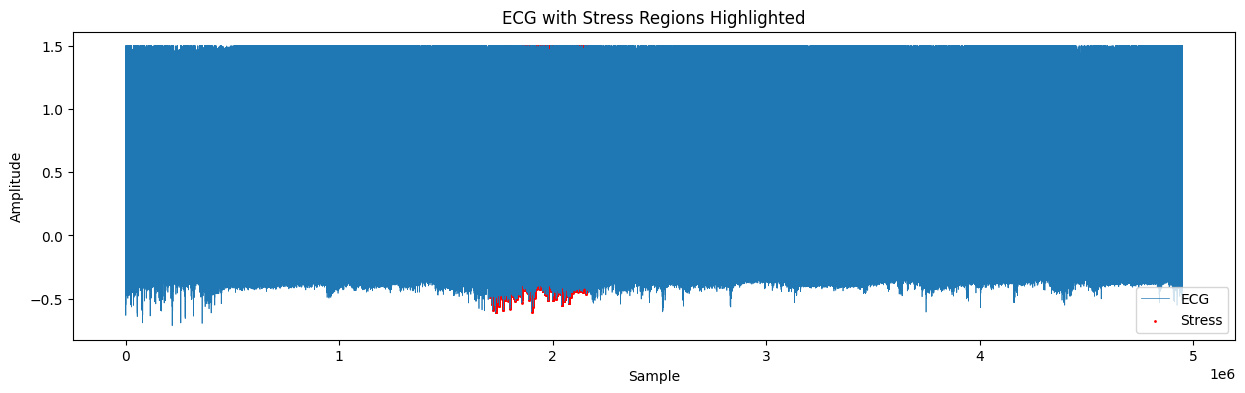

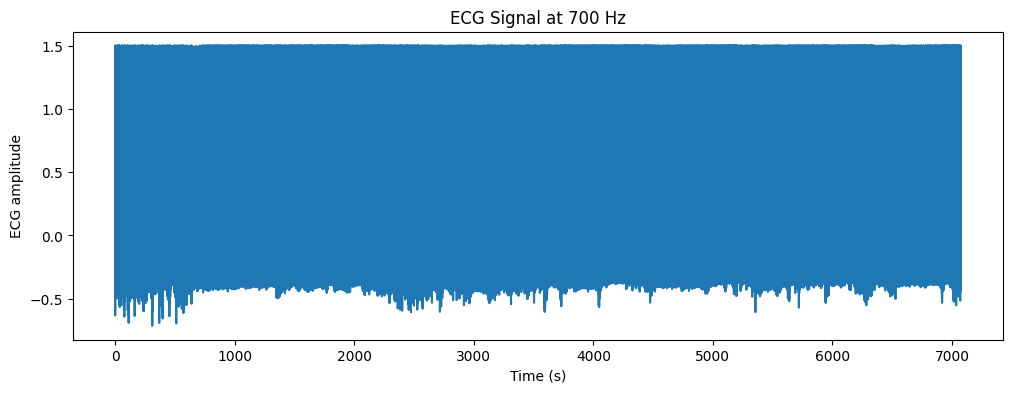

Patient: S7
Samples No Stress: 3218600
Samples Stress: 448000


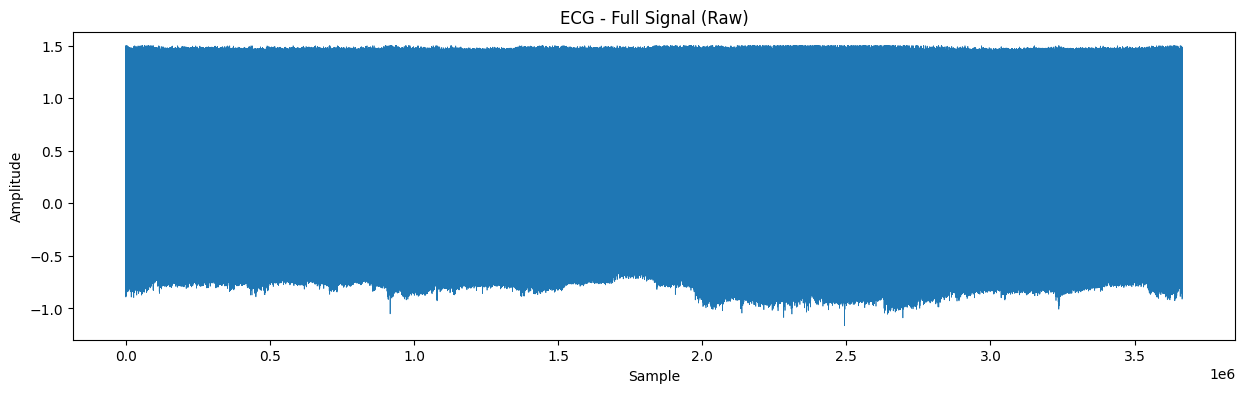

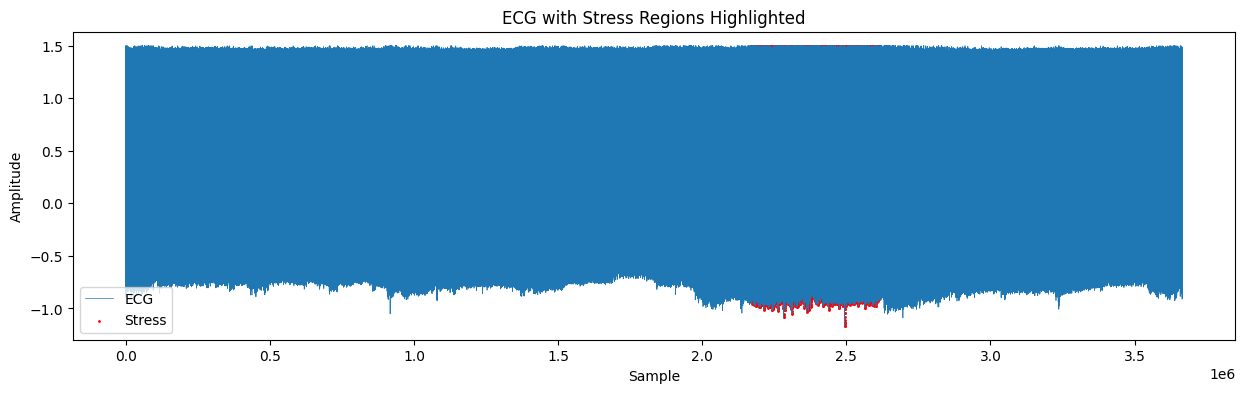

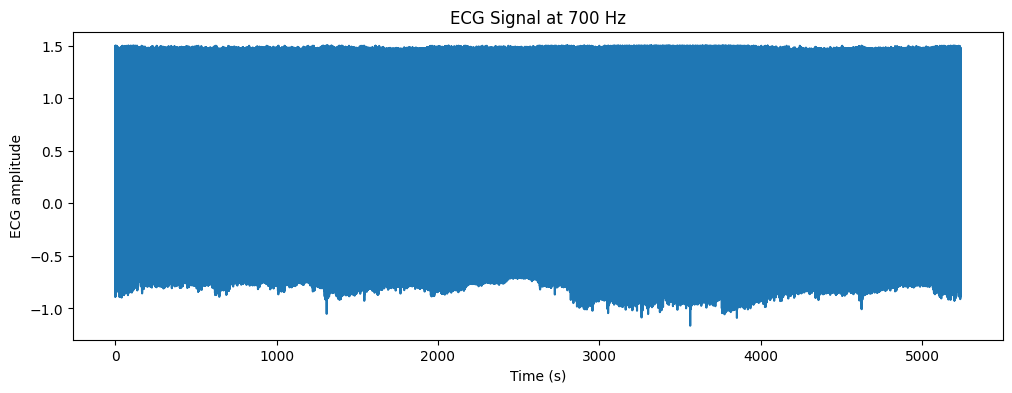

Patient: S8
Samples No Stress: 3357200
Samples Stress: 469000


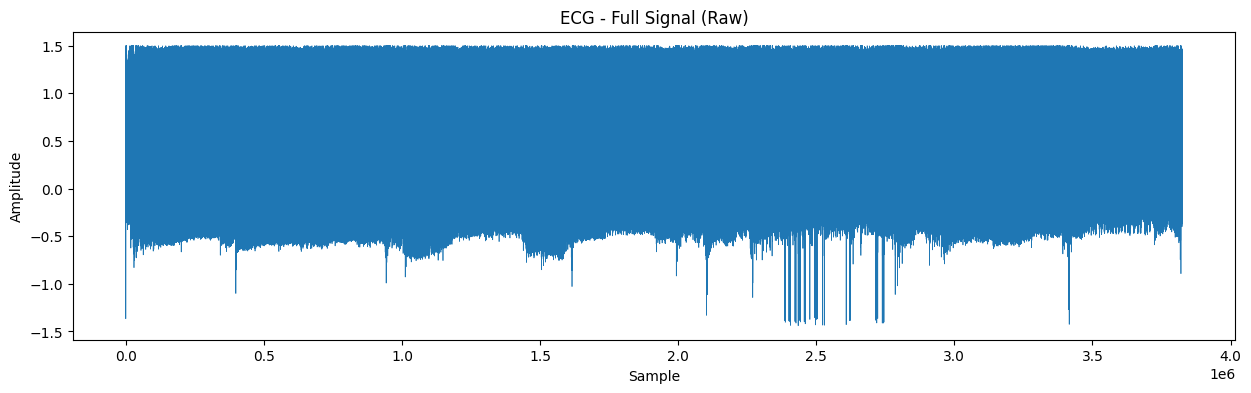

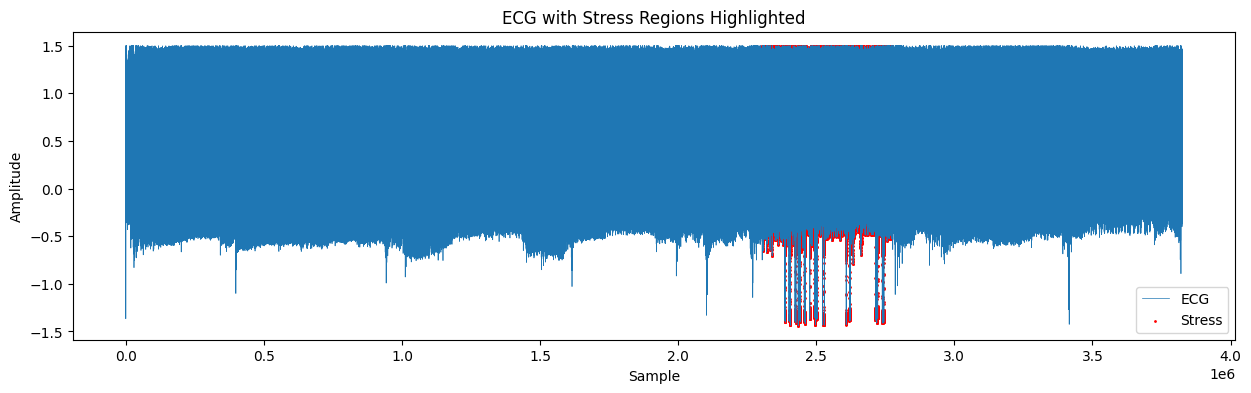

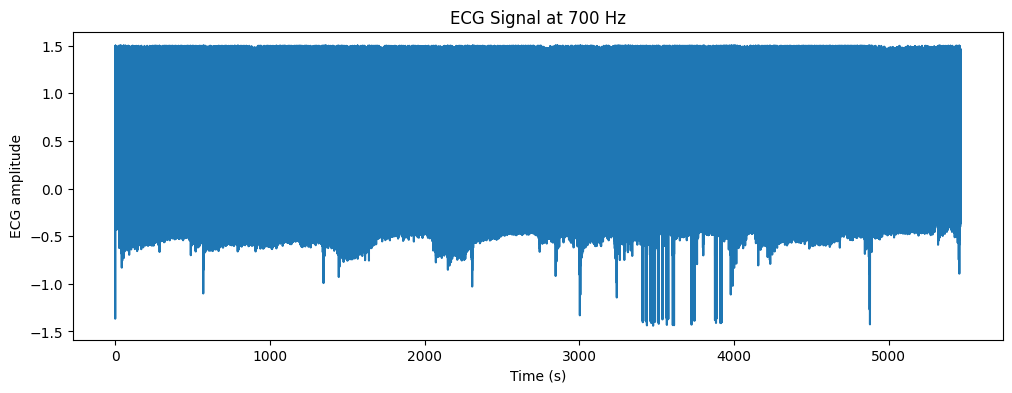

Patient: S9
Samples No Stress: 3204600
Samples Stress: 451500


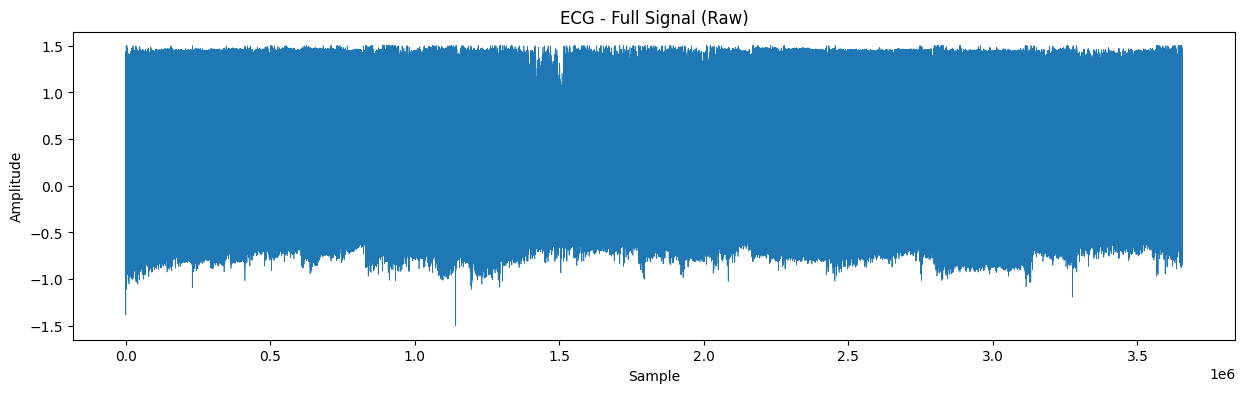

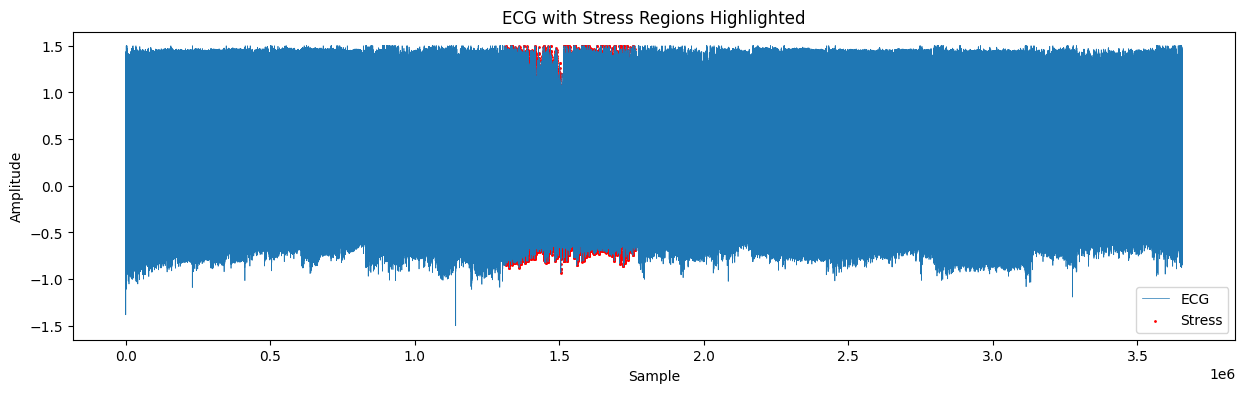

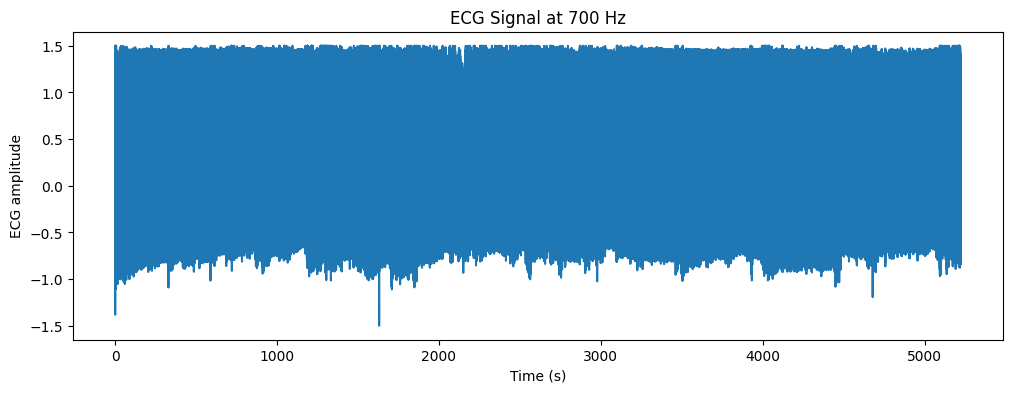

In [ ]:
def analyze_ecg(patient_file, fs=700, plot_full=True, plot_highlight=True, plot_time=True):

    # Load data
    with open(patient_file, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = data["signal"]["chest"]["ECG"].flatten()
    labels = data["label"]

    # Convert labels into binary (0 = no stress, 1 = stress)
    binary_labels = np.zeros_like(labels)
    binary_labels[labels == 2] = 1

    # Extract ECG segments by class
    ecg_no_stress = ecg[binary_labels == 0]
    ecg_stress = ecg[binary_labels == 1]

    print(f"Patient: {os.path.splitext(patient_file.split('/')[-1])[0]}")
    print("Samples No Stress:", len(ecg_no_stress))
    print("Samples Stress:", len(ecg_stress))

    # Plot full ECG signal
    if plot_full:
        plt.figure(figsize=(15,4))
        plt.plot(ecg, linewidth=0.5)
        plt.title("ECG - Full Signal (Raw)")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.show()

    # Plot ECG with stress segments highlighted
    if plot_highlight:
        plt.figure(figsize=(15,4))
        plt.plot(ecg, label="ECG", linewidth=0.5)
        stress_idx = np.where(binary_labels == 1)[0]
        plt.scatter(stress_idx, ecg[stress_idx], s=1, color="red", label="Stress")
        plt.title("ECG with Stress Regions Highlighted")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()

    # Plot ECG with time axis
    if plot_time:
        N = len(ecg)
        time = np.arange(N) / fs  # in seconds
        plt.figure(figsize=(12,4))
        plt.plot(time, ecg)
        plt.xlabel("Time (s)")
        plt.ylabel("ECG amplitude")
        plt.title(f"ECG Signal at {fs} Hz")
        plt.show()

    return ecg, binary_labels, ecg_no_stress, ecg_stress

for pf in patient_files:
    analyze_ecg(pf)

# Data Cleaning

In this step, we apply a Butterworth bandpass filter to the ECG signals recorded at 700 Hz from the chest channel. The filter is designed to retain frequencies between 0.5 Hz and 40 Hz, which correspond to the physiologically meaningful range for ECG analysis.

The low cutoff at 0.5 Hz removes slow baseline drifts caused by movement artifacts or respiration, while the high cutoff at 40 Hz eliminates high-frequency noise, including muscle activity or electrical interference.

We apply the filter using zero-phase filtering with filtfilt to ensure that the timing and shape of the ECG features, such as R-peaks, are preserved. This preprocessing step allows us to clean and standardize the signal across all patients.

In [ ]:
def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=700, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered

Now, the ECG signal is standardized to have zero mean and unit variance, ensuring that signals from different patients are on a comparable scale and facilitating further analysis.

After standardization, the bandpass filter previously defined is applied to remove baseline drift and high-frequency noise while preserving the shape and timing of key ECG features, such as R-peaks.

Finally, if visualization is enabled, the standardized and filtered signals are plotted over time to provide a clear visual assessment of the preprocessing effects.

This complete workflow ensures that the ECG data is clean, normalized, and correctly labeled

In [ ]:
def preprocess_ecg(patient_file, plot=True):

    # Load ECG
    with open(patient_file, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = data["signal"]["chest"]["ECG"].flatten()
    labels = data["label"]

    # Convert labels to binary
    binary_labels = np.zeros_like(labels)
    binary_labels[labels == 2] = 1

    # Standardization
    ecg_std = (ecg - np.mean(ecg)) / np.std(ecg)

    # Bandpass filter
    ecg_filtered = bandpass_filter(ecg_std)

    # Plot
    if plot:
        time = np.arange(len(ecg)) / fs
        plt.figure(figsize=(15,4))
        plt.plot(time, ecg_std, label="Standardized ECG", alpha=0.5)
        plt.plot(time, ecg_filtered, label="Filtered ECG", linewidth=1)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.title(f"ECG Preprocessing - {patient_file.split('/')[-1]}")
        plt.legend()
        plt.show()

    return ecg_filtered, binary_labels

The ECG signals cleaned through the preprocessing function are stored in the all_ecg_cleaned dictionary, while the corresponding binary labels are saved in the all_labels dictionary, using each patient file as the key to organize and retain the data for further analysis.

In [ ]:
all_ecg_cleaned = {}
all_labels = {}

for pf in patient_files:
    ecg_clean, labels = preprocess_ecg(pf, plot=False)  # plot=True if you want to visualize
    all_ecg_cleaned[pf] = ecg_clean
    all_labels[pf] = labels

Finally, we provide the visualization of the ECG signal of a single patient to illustrate the effect of our preprocessing pipeline. First, we display the original raw ECG signal recorded from the chest channel, and then we show the same signal after standardization and bandpass filtering.

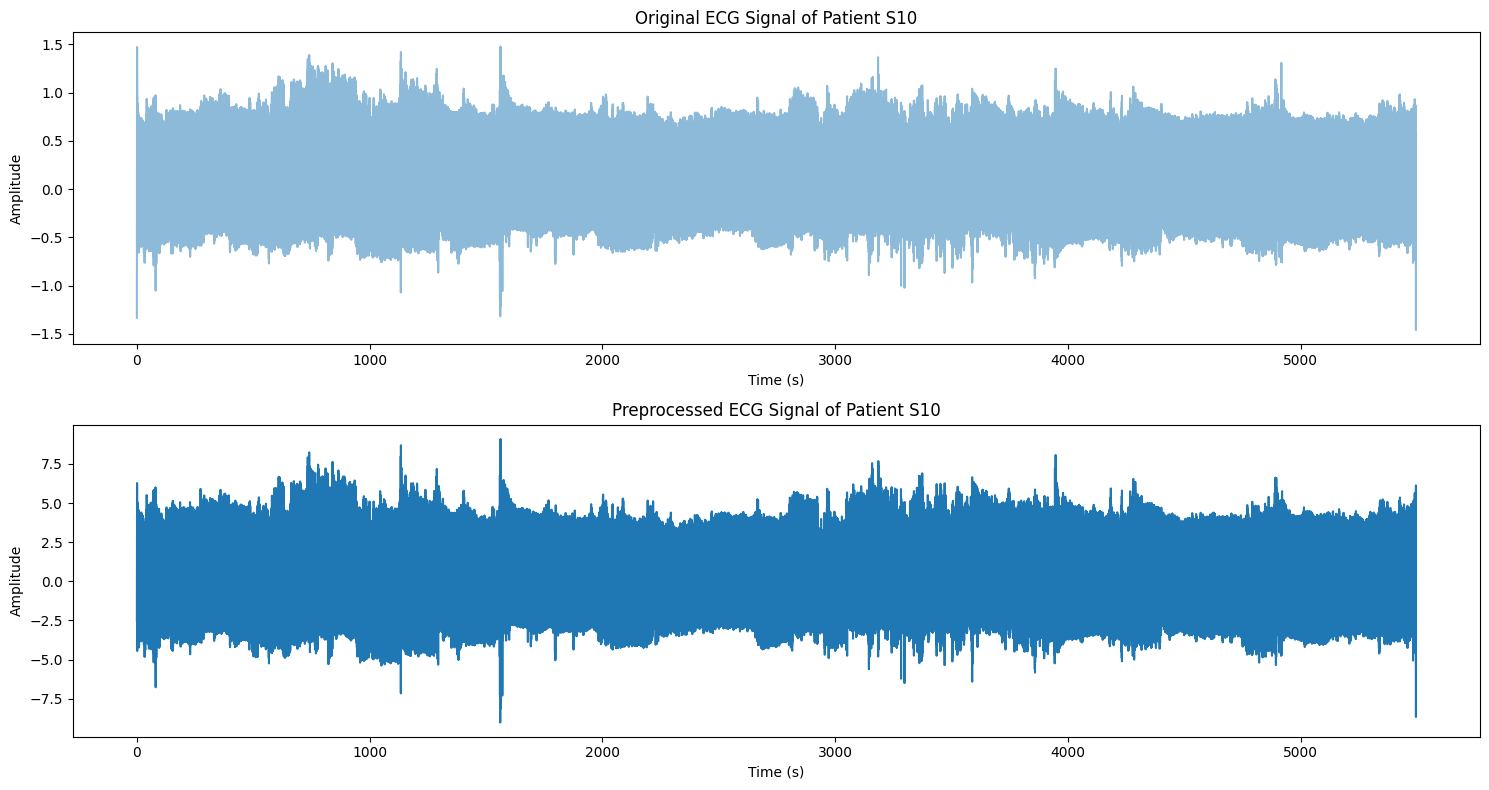

In [ ]:
# Select which patient to consider
patient_file = patient_files[0]
patient_name = os.path.basename(patient_file).replace(".pkl", "")

with open(patient_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")
ecg = data["signal"]["chest"]["ECG"].flatten()
labels = data["label"]
binary_labels = np.zeros_like(labels)
binary_labels[labels == 2] = 1
ecg_no_stress = ecg[binary_labels == 0]
ecg_stress = ecg[binary_labels == 1]


# Standardization
ecg_std = (ecg - np.mean(ecg)) / np.std(ecg)
# Bandpass filter
ecg_filtered = bandpass_filter(ecg_std)

N = len(ecg)
time = np.arange(N) / fs


# Plot Layout

plt.figure(figsize=(15,8))

# Original ECG signal
plt.subplot(2, 1, 1)
plt.plot(time, ecg, label="ECG", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Original ECG Signal of Patient {patient_name}")

# Preprocessed ECG signal
plt.subplot(2, 1, 2)
plt.plot(time, ecg_filtered, label="Standardized + Filtered ECG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Preprocessed ECG Signal of Patient {patient_name}")


plt.tight_layout()
plt.show()


# Segmentation

In this step, we segment the preprocessed ECG signals into fixed-length windows to structure the data for subsequent analysis and classification.

Each window is 7000 samples long, corresponding to 10 seconds at a 700 Hz sampling rate, with a 50% overlap between consecutive windows. This overlapping window approach is chosen to capture temporal continuity in the signal and to reduce the risk of losing transitions between stress and no-stress periods.

For each patient, we iterate over the filtered ECG signal and the corresponding binary labels obtained in the previous preprocessing step, extracting segments of the signal along with their associated labels.

The label of each window is determined using a majority vote over the samples within that window, assigning a stress label if the majority of samples indicate stress, and no-stress otherwise. This method ensures that each window has a single, robust label and reduces the influence of isolated noisy samples.

The segmented ECG windows and their labels are stored in dictionaries for each patient, keeping the data organized and accessible for feature extraction or machine learning tasks.

In summary, this choice is consistent with the previous preprocessing steps, as it transforms the continuous, filtered, and standardized ECG signal into well-structured, labeled segments that are ready for classification while preserving the temporal dynamics of the signal.

In [ ]:
window_size = 7000   # 10 seconds
step_size = 3500     # 50% overlap

# Dictionaries to save windows and labels for each patient
segments_per_patient = {}
labels_per_patient = {}

for pf in all_ecg_cleaned.keys():
    ecg_filtered = all_ecg_cleaned[pf]
    binary_labels = all_labels[pf]

    ecg_segments = []
    label_segments = []

    for start in range(0, len(ecg_filtered) - window_size + 1, step_size):
        end = start + window_size
        ecg_win = ecg_filtered[start:end]
        labels_win = binary_labels[start:end]

        # Label of the window: majority vote
        window_label = 1 if np.sum(labels_win) > len(labels_win)/2 else 0

        ecg_segments.append(ecg_win)
        label_segments.append(window_label)

    ecg_segments = np.array(ecg_segments)
    label_segments = np.array(label_segments)

    # Save to dictionaries
    segments_per_patient[pf] = ecg_segments
    labels_per_patient[pf] = label_segments

    print(f"Patient {os.path.basename(pf).replace(".pkl", "")} - Number of Windows: {len(ecg_segments)}, Label Distribution: {np.bincount(label_segments)}")


Patient S10 - Number of Windows: 1098, Label Distribution: [953 145]
Patient S11 - Number of Windows: 1045, Label Distribution: [909 136]
Patient S13 - Number of Windows: 1106, Label Distribution: [974 132]
Patient S14 - Number of Windows: 1108, Label Distribution: [973 135]
Patient S15 - Number of Windows: 1049, Label Distribution: [911 138]
Patient S16 - Number of Windows: 1125, Label Distribution: [990 135]
Patient S17 - Number of Windows: 1183, Label Distribution: [1038  145]
Patient S2 - Number of Windows: 1214, Label Distribution: [1091  123]
Patient S3 - Number of Windows: 1297, Label Distribution: [1169  128]
Patient S4 - Number of Windows: 1283, Label Distribution: [1156  127]
Patient S5 - Number of Windows: 1250, Label Distribution: [1121  129]
Patient S6 - Number of Windows: 1413, Label Distribution: [1283  130]
Patient S7 - Number of Windows: 1046, Label Distribution: [918 128]
Patient S8 - Number of Windows: 1092, Label Distribution: [958 134]
Patient S9 - Number of Window

The output shows that the majority of segments are labeled as no-stress, reflecting the imbalance in the dataset, while a smaller portion corresponds to stress. This provides an initial overview of the data available for classification and highlights the class imbalance that will need to be considered in model training.

# Feature Extraction

The feature extraction phase begins by focusing on time-domain characteristics of the preprocessed ECG signal.

For each ECG window, we compute a set of descriptive statistics and signal dynamics measures that summarize its amplitude distribution, energy content, and temporal variability.

These features, including basic statistics, zero-crossing rate, and Hjorth parameters, are designed to capture both the overall behavior and the intrinsic complexity of the ECG signal over time

In [ ]:
def time_domain_features(ecg_win):
    x = ecg_win

    # Base statistics
    mean = np.mean(x)
    std = np.std(x)
    rms = np.sqrt(np.mean(x**2))
    ptp = np.ptp(x)

    # Zero-crossing rate
    zcr = ((x[:-1] * x[1:]) < 0).sum() / len(x)

    # Energy
    energy = np.sum(x**2)

    # Hjorth
    dx = np.diff(x)
    ddx = np.diff(dx)
    activity = np.var(x)
    mobility = np.sqrt(np.var(dx) / activity)
    complexity = np.sqrt(np.var(ddx)/np.var(dx)) / mobility

    return [mean, std, rms, ptp, zcr, energy, activity, mobility, complexity]


The following function extends the feature extraction process to the frequency domain by analyzing the spectral content of each ECG window.

The power spectral density is estimated using Welch’s method, which provides a robust representation of how signal energy is distributed across frequencies. From this spectrum, power is computed in the low-frequency and high-frequency bands, which are commonly associated with autonomic nervous system activity.

The ratio between low- and high-frequency power is then derived to capture the balance between sympathetic and parasympathetic components.

In [ ]:
def freq_domain_features(ecg_win, fs=700):

    f, Pxx = welch(ecg_win, fs=fs, nperseg=1024)

    # LF power
    lf_band = (f >= 0.04) & (f < 0.15)
    hf_band = (f >= 0.15) & (f <= 0.40)
    lf_power = np.trapezoid(Pxx[lf_band], f[lf_band])
    hf_power = np.trapezoid(Pxx[hf_band], f[hf_band])
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

    return [lf_power, hf_power, lf_hf_ratio]


The focus is now shifted on extracting heart rate variability (HRV) features from each ECG window, which provide insight into autonomic nervous system regulation.

R-peaks are first detected from the ECG signal and used to compute successive R-R intervals. From these intervals, standard time-domain HRV metrics are derived, including measures of overall variability, short-term fluctuations, and average heart rate.

A safeguard is included to handle windows with insufficient detected beats, ensuring robustness of the feature extraction process.

These HRV descriptors complement the time and frequency  features by capturing beat-to-beat dynamics.

In [ ]:
def hrv_features(ecg_win, fs=700):

    _, rpeaks = nk.ecg_peaks(ecg_win, sampling_rate=fs)
    rri = np.diff(rpeaks['ECG_R_Peaks']) / fs

    if len(rri) < 2:
        return [np.nan]*4  # now we have 4 HRV features

    sdnn = np.std(rri)
    rmssd = np.sqrt(np.mean(np.diff(rri)**2))
    pnn50 = np.sum(np.diff(rri) > 0.05) / len(rri)
    hr_mean = 60 / np.mean(rri)

    return [sdnn, rmssd, pnn50, hr_mean]


Finally, feature extraction is performed at the window level for each patient by systematically applying the previously defined time-domain, frequency-domain, and HRV functions to every segmented ECG window.

For each patient, all feature types are computed separately and then concatenated into a single feature vector, ensuring that complementary information from different signal representations is jointly captured.

The resulting feature matrices are stored patient-wise, together with their corresponding window labels, preserving the structure established during segmentation.

In [ ]:
# Dictionaries to hold features and labels per patient
features_per_patient = {}
labels_per_patient_features = {}

for pf in segments_per_patient.keys():
    ecg_windows = segments_per_patient[pf]
    labels_windows = labels_per_patient[pf]

    patient_features = []

    for ecg_win in ecg_windows:

        # Time-domain
        time_features = time_domain_features(ecg_win)

        # Frequency-domain
        freq_features = freq_domain_features(ecg_win)

        # HRV
        hrv_feats = hrv_features(ecg_win)

        # Concatenate all the features
        feats = np.array(time_features + freq_features + hrv_feats)
        patient_features.append(feats)

    features_per_patient[pf] = np.array(patient_features)
    labels_per_patient_features[pf] = labels_windows

    print(f"Patient {os.path.basename(pf).replace(".pkl", "")} - Windows: {len(patient_features)}, Shape features per window: {patient_features[0].shape}")


Patient S10 - Windows: 1098, Shape features per window: (16,)
Patient S11 - Windows: 1045, Shape features per window: (16,)
Patient S13 - Windows: 1106, Shape features per window: (16,)
Patient S14 - Windows: 1108, Shape features per window: (16,)
Patient S15 - Windows: 1049, Shape features per window: (16,)
Patient S16 - Windows: 1125, Shape features per window: (16,)
Patient S17 - Windows: 1183, Shape features per window: (16,)
Patient S2 - Windows: 1214, Shape features per window: (16,)
Patient S3 - Windows: 1297, Shape features per window: (16,)
Patient S4 - Windows: 1283, Shape features per window: (16,)
Patient S5 - Windows: 1250, Shape features per window: (16,)
Patient S6 - Windows: 1413, Shape features per window: (16,)
Patient S7 - Windows: 1046, Shape features per window: (16,)
Patient S8 - Windows: 1092, Shape features per window: (16,)
Patient S9 - Windows: 1043, Shape features per window: (16,)


The output shows that feature extraction has been successfully completed for all patients. For each subject, the ECG signal has been segmented into a patient-specific number of overlapping windows, reflecting differences in signal length.

From every window, a fixed feature vector of dimension 16 is extracted, obtained by concatenating time-domain, frequency-domain, and HRV features. This confirms that the feature representation is consistent across patients, while preserving inter-patient variability in the number of available segments, and that the data are now in a suitable structured form for subsequent stress classification and modeling steps.

The following objects are saved to disk so that they can be reliably reused in the final demo, ensuring consistency between the data preparation steps and the model evaluation on the unseen patient.

In [ ]:
save_path = "/content/drive/MyDrive"

features_file = os.path.join(save_path, "features_per_patient.pkl")
labels_file = os.path.join(save_path, "labels_per_patient.pkl")

joblib.dump(features_per_patient, features_file)
joblib.dump(labels_per_patient_features, labels_file)

['/content/drive/MyDrive/labels_per_patient.pkl']

# Train and Test Split

In this section, the dataset preparation for model training is completed by performing a train-test split at the patient level, followed by the concatenation of data across patients and a final standardization step.

## Train-Test Split by Patient (Subject-wise Split)

Firstly, the train-test split is performed at the patient level to prevent data leakage. Out of the available subjects, 12 patients are assigned to the training set and 2 patients to the test set, while one additional patient is deliberately excluded from this phase.

This remaining patient is not involved in the training-testing procedure and is reserved for a final evaluation, where it is used as the basis for a pseudo-demo of the best-performing model.

In [ ]:
all_patients = list(features_per_patient.keys())

# randomly assignment of patients to train and test sets
random.seed(42)
random.shuffle(all_patients)

# train-test split by patients
train_patients = all_patients[:12]
test_patients = all_patients[12:14]
demo_patient = all_patients[14:]

print("Train:", [os.path.basename(pf).replace(".pkl", "") for pf in train_patients])
print("Test:", [os.path.basename(pf).replace(".pkl", "") for pf in test_patients])
print("Demo Patient:", [os.path.basename(pf).replace(".pkl", "") for pf in demo_patient])


Train: ['S3', 'S8', 'S2', 'S17', 'S9', 'S7', 'S16', 'S13', 'S4', 'S14', 'S15', 'S6']
Test: ['S10', 'S11']
Demo Patient: ['S5']


## Creating Train and Test Sets (Concatenation of Patient Data)

After splitting the dataset at the patient level, the feature matrices and corresponding labels from all training patients are concatenated to form a single training set, and the same procedure is applied to the test patients. This step aggregates window-level observations across different individuals, increasing the number of samples available for learning while preserving the independence between training and test subjects.

As a result, the model is exposed to a broader variability of ECG patterns during training and can be evaluated on a sufficiently large and representative test set.

In [ ]:
# Train
X_train = np.concatenate([features_per_patient[p] for p in train_patients], axis=0)
y_train = np.concatenate([labels_per_patient_features[p] for p in train_patients], axis=0)

# Test
X_test = np.concatenate([features_per_patient[p] for p in test_patients], axis=0)
y_test = np.concatenate([labels_per_patient_features[p] for p in test_patients], axis=0)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train Distribution:", np.bincount(y_train))
print("Test Distribution:", np.bincount(y_test))

Train shape: (13959, 16) (13959,)
Test shape: (2143, 16) (2143,)
Train Distribution: [12375  1584]
Test Distribution: [1862  281]


The output shows that the training set contains 13,959 windows and the test set 3,393 windows, each represented by 16 extracted features, confirming a consistent feature dimensionality across splits. The label distributions indicate a clear class imbalance in both sets, with the no-stress class largely predominant over the stress class.

Importantly, the imbalance is similar in training and test data, which suggests that the patient-wise split and concatenation preserve the original class proportions and allow for a fair and coherent evaluation of the classification models.

## Feature Standardization (Z-score Normalization)


Finally, feature standardization is applied to place all features on a comparable scale, preventing those with larger numerical ranges from dominating the learning process and improving the stability and performance of the classification models.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We store the scaling statistics computed on the training set, namely the mean and standard deviation, which will later be reused to standardize the data of the patient reserved for the demo.

This ensures that the same normalization applied during training is consistently used when evaluating the model on unseen data.

In [ ]:
scaler_stats = {
    "mean": scaler.mean_,
    "scale": scaler.scale_
}

save_path = "/content/drive/MyDrive"

scaler_file = os.path.join(save_path, "scaler_stats.pkl")
patient_file = os.path.join(save_path, "patient_file.pkl")

joblib.dump(scaler_stats, scaler_file)
joblib.dump(demo_patient, patient_file)

['/content/drive/MyDrive/patient_file.pkl']

In [ ]:
patient_files[10] # s5

'/content/drive/MyDrive/WESAD/S5.pkl'

We save all relevant information for patient S5, which will later be used as the basis for the demo to evaluate the best classification model.

In [ ]:
patient_file = patient_files[10]  # Select patient not involved in train-test (S5)
patient_name = os.path.basename(patient_file).replace(".pkl", "")

with open(patient_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Extract ECG signal and labels
ecg = data["signal"]["chest"]["ECG"].flatten()
labels = data["label"]
# Convert labels to binary: 0 = no stress, 1 = stress
binary_labels = np.zeros_like(labels)
binary_labels[labels == 2] = 1
# Segment ECG according to class
ecg_no_stress = ecg[binary_labels == 0]
ecg_stress = ecg[binary_labels == 1]

save_path = "/content/drive/MyDrive"
os.makedirs(save_path, exist_ok=True)

# Saving Statistics about S5
ecg_stats = {
    "ecg": ecg,
    "binary_labels": binary_labels,
    "ecg_no_stress": ecg_no_stress,
    "ecg_stress": ecg_stress
}

ecg_file = os.path.join(save_path, "ecg_stats_s5.pkl")
joblib.dump(ecg_stats, ecg_file)

['/content/drive/MyDrive/ecg_stats_s5.pkl']

# Classification

In this final section, a series of classification approaches are implemented to distinguish stress from no-stress conditions based on ECG signals, all centered around the Support Vector Classifier (SVC) due to its effectiveness in handling high-dimensional feature spaces, robustness to overfitting, and ability to work well with medium-sized datasets.

The methods include training a baseline SVC on the original unbalanced data to provide a reference point, applying oversampling techniques like SMOTE to address class imbalance, exploring various undersampling strategies combined with SVC to balance the training set, and finally employing an ensemble learning approach that integrates Bagging with SVC to enhance stability and generalization.

This progression allows a systematic evaluation of the impact of sampling strategies and ensemble methods on model performance, ensuring that the chosen classifier is both reliable and capable of generalizing to unseen patient data.


## Baseline: SVC with Grid Search

This first technique implements a baseline SVC model trained on the original unbalanced data to provide a reference point for the following approaches.

This allows us to evaluate the effect of sampling strategies by first establishing the model’s performance on the raw dataset, using cross-validation to optimize hyperparameters and account for class imbalance.

This step applies an SVC model with class_weight='balanced' to partially address class imbalance, performing a grid search over various kernels, regularization strengths, and kernel coefficients using 5-fold cross-validation with macro F1 scoring.

The procedure determines the optimal hyperparameters to be used for subsequent evaluation.

In [ ]:
svc = SVC(class_weight='balanced', random_state=42)

# Parameters grid to test
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation F1 score: 0.6862670751320105


Finally, the best model is evaluated on the test set, with a classification report printed to assess its performance, and the class distribution in the training and test sets is checked to highlight the imbalance.

In [ ]:
# Prediction and evaluation
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_scaled)

print("Classification Report SVC + GridSearchCV:\n")
print(classification_report(y_test, y_pred))

# Classes distribution
print("Train Classes Distribution:", np.bincount(y_train))
print("Test Classes Distribution:", np.bincount(y_test))

Classification Report SVC + GridSearchCV:

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1862
           1       0.46      0.83      0.59       281

    accuracy                           0.85      2143
   macro avg       0.71      0.84      0.75      2143
weighted avg       0.90      0.85      0.86      2143

Train Classes Distribution: [12375  1584]
Test Classes Distribution: [1862  281]


The baseline SVC shows high overall accuracy (90%) and performs very well on the majority class (no-stress) with strong precision and recall. However, performance on the minority class (stress) is substantially lower, particularly in precision (0.46), indicating that many stress samples are misclassified as no-stress.

This highlights the impact of class imbalance and demonstrates the need for resampling or ensemble strategies to improve detection of the stress condition.

## SMOTE + SVC (Grid Search)

The second supervised classification approach relies on Support Vector Machines to discriminate between stress and no-stress conditions. This method integrates explicit class imbalance handling with systematic hyperparameter tuning through grid search, aiming to learn a robust decision boundary and to ensure reliable generalization to unseen data.


SMOTE is first applied exclusively to the training data to generate synthetic samples of the minority class, improving class balance without introducing information leakage from the test set.

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print("Classes distribution after SMOTE:", np.bincount(y_res))


Classes distribution after SMOTE: [12375 12375]


SVC model is then selected due to its effectiveness in handling high-dimensional feature spaces, and the use of class-weight balancing further mitigates residual imbalance during learning.

Model performance is optimized through a grid search over key hyperparameters, allowing the classifier to adapt both linear and non-linear decision boundaries.

Cross-validation with an F1-macro scoring strategy is employed to ensure that performance is evaluated equally across classes rather than being dominated by the majority class.

In [ ]:
svc = SVC(class_weight='balanced', random_state=42)

# parameters grid to test
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='f1_macro',    # macro f1 for imbalanced classes
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_res, y_res)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1 score: 0.831942313216943


Finally, the best-performing model is assessed on the unseen test set, where standard classification metrics are reported to provide a clear and interpretable evaluation of generalization performance.

In [ ]:
# Prediction and evaluation
best_svc_smote = grid_search.best_estimator_
y_pred = best_svc_smote.predict(X_test_scaled)

print("Classification Report SMOTE + GridSearchCV SVC:\n")
print(classification_report(y_test, y_pred))

Classification Report SMOTE + GridSearchCV SVC:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1862
           1       0.50      0.38      0.43       281

    accuracy                           0.87      2143
   macro avg       0.70      0.66      0.68      2143
weighted avg       0.86      0.87      0.86      2143



The SVC model trained with SMOTE shows a slight drop in overall accuracy (87%) compared to the baseline. While the majority class (no-stress) remains well-classified, the minority class (stress) performance worsens, with low recall (0.38) and F1-score (0.43).

This suggests that the synthetic oversampling introduced by SMOTE may have created noisy or unrepresentative stress samples, making the classifier more conservative and less able to correctly identify true stress events.

## Different Undersampling Techniques + SVC

This third approach implements SVC-based classification combined with different undersampling techniques to effectively address class imbalance.

Each method creates a balanced training set, allowing the model to learn more effectively, while hyperparameter tuning via GridSearchCV ensures optimal performance before evaluation on the test set.

Different undersampling methods, including RandomUnderSampler and the three variants of NearMiss, are applied to the training data to obtain balanced datasets through different selection criteria.

For each resampled dataset, the same SVC hyperparameter grid is explored using GridSearchCV with 5-fold cross-validation and f1_macro as the evaluation metric, ensuring a fair comparison across methods.

In [ ]:
undersamplers = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3)
}

# Parameter grid for SVC
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Dictionary to store best models for each undersampler
best_models = {}

for name, sampler in undersamplers.items():
    # Resample training data
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    print(f"\n{name} - Classes distribution after resampling:", np.bincount(y_res))

    # SVC initialization
    svc = SVC(class_weight='balanced', random_state=42)

    # Grid search with cross-validation
    grid_search = GridSearchCV(
        estimator=svc,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=2
    )

    # Fitting model on resampled data
    grid_search.fit(X_res, y_res)

    # Store the best estimator
    best_models[name] = grid_search.best_estimator_

    print(f"\n{name} - Best parameters:", grid_search.best_params_)
    print(f"{name} - Best cross-validation F1 score:", grid_search.best_score_)



RandomUnderSampler - Classes distribution after resampling: [1584 1584]
Fitting 5 folds for each of 12 candidates, totalling 60 fits

RandomUnderSampler - Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
RandomUnderSampler - Best cross-validation F1 score: 0.7607869497150028

NearMiss_v1 - Classes distribution after resampling: [1584 1584]
Fitting 5 folds for each of 12 candidates, totalling 60 fits

NearMiss_v1 - Best parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
NearMiss_v1 - Best cross-validation F1 score: 0.6889270977081862

NearMiss_v2 - Classes distribution after resampling: [1584 1584]
Fitting 5 folds for each of 12 candidates, totalling 60 fits

NearMiss_v2 - Best parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
NearMiss_v2 - Best cross-validation F1 score: 0.7376042340492462

NearMiss_v3 - Classes distribution after resampling: [1584 1584]
Fitting 5 folds for each of 12 candidates, totalling 60 fits

NearMiss_v3 - Best parameters: {'C': 10, '

The best model obtained for each undersampling technique is now tested on the held-out test set, and the resulting classification reports are used to assess and compare their performance in distinguishing stress from no-stress conditions.

In [ ]:
for name, model in best_models.items():
    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Classification report
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, y_pred))



Classification Report for RandomUnderSampler:

              precision    recall  f1-score   support

           0       0.97      0.86      0.91      1862
           1       0.47      0.83      0.60       281

    accuracy                           0.85      2143
   macro avg       0.72      0.84      0.76      2143
weighted avg       0.91      0.85      0.87      2143


Classification Report for NearMiss_v1:

              precision    recall  f1-score   support

           0       1.00      0.51      0.68      1862
           1       0.24      1.00      0.38       281

    accuracy                           0.58      2143
   macro avg       0.62      0.76      0.53      2143
weighted avg       0.90      0.58      0.64      2143


Classification Report for NearMiss_v2:

              precision    recall  f1-score   support

           0       1.00      0.12      0.22      1862
           1       0.15      1.00      0.25       281

    accuracy                           0.24      214

The undersampling experiments show varying effects on classification performance depending on the strategy used.

- RandomUnderSampler closely replicates the baseline results, maintaining high accuracy (85%) and strong recall for the stress class (0.83), indicating that random reduction of majority class samples preserves useful information without substantially degrading performance.

- NearMiss_v1 prioritizes minority class proximity, achieving perfect recall for stress (1.00) but at the cost of a severe drop in majority class performance (recall 0.51), resulting in lower overall accuracy (58%) and demonstrating a clear trade-off between sensitivity to stress and misclassifying no-stress samples.

- NearMiss_v2 produces extreme imbalance in predictions, heavily favoring the minority class with very low precision (0.15 for stress) and overall accuracy (24%), making it ineffective in this context.

- NearMiss_v3 achieves a more balanced compromise, with improved stress recall (0.75) while maintaining strong performance for the majority class (recall 0.92), leading to the highest overall accuracy among the NearMiss variants (90%) and a relatively balanced F1 across both classes.

Overall, these results illustrate that the choice of undersampling method critically affects the trade-off between sensitivity to stress events and overall classification accuracy, with NearMiss_v3 emerging as the most effective approach in this dataset.

## Bootstrap Aggregating + SVC

This final approach employs an ensemble learning strategy that integrates Bagging with a Support Vector Classifier (SVC) to improve model stability and boost generalization performance.

A base SVC model is defined with class_weight='balanced' and its hyperparameters are tuned within the Bagging ensemble using GridSearchCV with 5-fold cross-validation and macro F1 scoring.

The Bagging model is configured with ten base estimators, each trained on 80% of the data with bootstrap sampling, and executed in parallel for efficiency.

After training on the original dataset, the best hyperparameters and cross-validation score are identified.

In [ ]:
svc_base = SVC(class_weight='balanced', random_state=42)


param_grid = {
    'estimator__kernel': ['rbf', 'linear'],
    'estimator__C': [0.1, 1, 10],
    'estimator__gamma': ['scale', 'auto']
}


bagging_model = BaggingClassifier(
    estimator=svc_base,
    n_estimators=10,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found (Bagging + SVC):", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found (Bagging + SVC): {'estimator__C': 0.1, 'estimator__gamma': 'scale', 'estimator__kernel': 'linear'}
Best cross-validation F1 score: 0.6884106605112038


Finally, the resulting ensemble is evaluated on the test set using a classification report to assess performance.

In [ ]:
best_bagging = grid_search.best_estimator_
y_pred = best_bagging.predict(X_test_scaled)

print("Classification Report - Bagging + GridSearchCV SVC:\n")
print(classification_report(y_test, y_pred))

Classification Report - Bagging + GridSearchCV SVC:

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      1862
           1       0.45      0.83      0.58       281

    accuracy                           0.84      2143
   macro avg       0.71      0.84      0.74      2143
weighted avg       0.90      0.84      0.86      2143



The Bagging ensemble combined with SVC shows results very similar to the baseline SVC model, with high precision and recall for the majority class (no-stress) and moderate performance for the minority class (stress). The ensemble achieves a stress recall of 0.83, comparable to the baseline, indicating that while variance reduction through Bagging stabilizes the predictions, it does not substantially increase sensitivity to stress events.

Overall accuracy remains at 84%, confirming that Bagging helps produce more consistent predictions without drastically altering the trade-off between detecting stress and maintaining overall performance.

# Model selected

Overall, among all the tested approaches, NearMiss v3 clearly emerged as the most effective strategy. It provided the best trade-off between precision and recall for both classes, enabling a more reliable discrimination between stress and no-stress conditions compared to the other models.

For our pseudo-demo, we therefore chose to retain the NearMiss v3 undersampling approach, as it allows the model to operate on a smaller and more balanced set of representative examples.


In [ ]:
# Undersampler
sampler = NearMiss(version=3)

# Resample training data
X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)

# Define SVC
svc = SVC(class_weight='balanced', random_state=42)

# Hyperparameter grid
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit model
grid_search.fit(X_res, y_res)

# Best model
best_model = grid_search.best_estimator_

# Save the model
save_path = "/content/drive/MyDrive"
model_file = os.path.join(save_path, "svc_nearmissV3_model.pkl")

joblib.dump(best_model, model_file)
print(f"Model saved at: {model_file}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Model saved at: /content/drive/MyDrive/svc_nearmissV3_model.pkl


# Pseudodemo

In this final section, we apply the model pre-trained on data from 14 patients to the remaining patient who was not included in the training-testing phase.

This evaluation is designed to assess how well the model generalizes to completely unseen data, providing insight into its ability to capture stress related patterns that extend beyond the subjects used during model development.

In [ ]:
# Load pre-saved objects
load_path = "/content/drive/MyDrive"

demo_patient = joblib.load(os.path.join(load_path, "patient_file.pkl"))
features_per_patient = joblib.load(os.path.join(load_path, "features_per_patient.pkl"))
labels_per_patient_features = joblib.load(os.path.join(load_path, "labels_per_patient.pkl"))
scaler_stats = joblib.load(os.path.join(load_path, "scaler_stats.pkl"))

X = np.concatenate([features_per_patient[p] for p in demo_patient], axis=0)
y = np.concatenate([labels_per_patient_features[p] for p in demo_patient], axis=0)

X_scaled = (X - scaler_stats["mean"]) / scaler_stats["scale"]

loaded_model = joblib.load(os.path.join(load_path, "svc_nearmissV3_model.pkl"))
y_pred = loaded_model.predict(X_scaled)

We now proceed to a graphical analysis of the model’s predictions.

In [ ]:
# Load S5 statistics
ecg_stats = joblib.load("/content/drive/MyDrive/ecg_stats_s5.pkl")

ecg = ecg_stats["ecg"]
binary_labels = ecg_stats["binary_labels"]
ecg_no_stress = ecg_stats["ecg_no_stress"]
ecg_stress = ecg_stats["ecg_stress"]

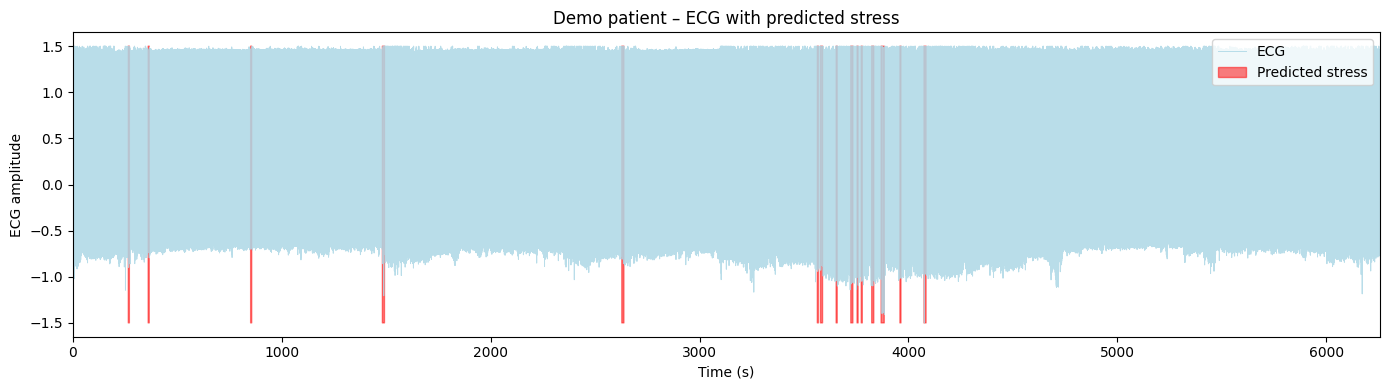

In [ ]:
def plot_ecg_with_prediction(ecg, y_pred, fs):
    N = len(ecg)
    time = np.arange(N) / fs

    samples_per_window = N // len(y_pred)
    pred_signal = np.repeat(y_pred, samples_per_window)

    if len(pred_signal) < N:
        pred_signal = np.pad(pred_signal, (0, N - len(pred_signal)), mode="edge")
    else:
        pred_signal = pred_signal[:N]

    fig, ax = plt.subplots(figsize=(14,4))

    # ECG
    ax.plot(
        time,
        ecg,
        color="lightblue",
        linewidth=0.7,
        alpha=0.85,
        label="ECG"
    )

    # Stress Bands
    ax.fill_between(
        time,
        ecg.min(),
        ecg.max(),
        where=pred_signal.astype(bool),
        color="red",
        alpha=0.5,
        label="Predicted stress"
    )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ECG amplitude")
    ax.set_title("Demo patient (S5) – ECG with predicted stress")

    ax.legend(loc="upper right")
    ax.margins(x=0)
    plt.tight_layout()
    plt.show()
plot_ecg_with_prediction(ecg, y_pred, fs=700)


The prediction highlights stress as short, sparse temporal segments rather than a continuous condition. Most of the ECG signal is classified as non-stress, with predicted stress appearing intermittently and clustering more clearly in the later part of the recording.

This suggests that the model is identifying transient physiological changes instead of labeling long sustained periods, which is consistent with a window-based classifier responding to localized ECG variations rather than global signal trends.